# Notebook 00 — Build and Validate the Canonical Course Dataset
## Teaching PCD Environmental GIS

**Instructor-only data builder**

Repository เป้าหมาย:

```text
https://github.com/nattaponm/Teaching_PCD_Environmental_GIS
```

Notebook นี้ใช้สำหรับผู้สอนรัน **เพียงครั้งเดียว** เพื่อสร้างชุดข้อมูลมาตรฐานสำหรับ Notebook 01–06

```text
nattaponm/training_PCD_data_GIS
        +
nattaponm/training_PCD_Ogimet10yr_3provinces_pm25
        +
prasertcbs/thailand_gis
        ↓
SOURCE INVENTORY
        ↓
QC / STANDARDIZATION
        ↓
PCD + OGIMET stations
        +
Province / Amphoe / Tambon
        ↓
CSV + GeoJSON + GeoPackage
        ↓
Manifest + SHA256 + ZIP
        ↓
Upload to Teaching_PCD_Environmental_GIS
```

หลังอัปโหลด canonical dataset แล้ว Notebook ของนิสิตจะ **ไม่ดึงข้อมูลจากเว็บไซต์ภายนอกอีก**

# วัตถุประสงค์

Notebook 00 ต้องทำให้ teaching data:

1. ใช้ข้อมูลชุดเดียวกันทุกคน
2. ตรวจ schema, missingness, coordinates, CRS และ geometry แล้ว
3. มี provenance ชัดเจน
4. มี manifest และ SHA256
5. พร้อมใช้ด้วย Pandas/GeoPandas
6. แพ็กเป็น ZIP สำหรับ GitHub

ข้อมูลหลัก:

- PCD/Air4Thai Excel 2021–2025
- PCD station metadata
- OGIMET/WMO station metadata ที่พบใน course sources
- Thailand province / amphoe / tambon polygons จาก `prasertcbs/thailand_gis`

# Canonical package structure

```text
Teaching_PCD_Environmental_GIS_Data_v1/
├── raw_reference/
│   ├── PCD_Excel/
│   │   ├── 2021.xlsx ... 2025.xlsx
│   └── GIS_source/
│       ├── province_simplify_source.zip
│       ├── amphoe_simplify_source.zip
│       └── tambon_simplify_source.zip
├── processed/
│   ├── pcd_air4thai_stations.csv
│   ├── pcd_air4thai_stations.geojson
│   ├── ogimet_wmo_stations_from_course_sources.csv
│   ├── ogimet_wmo_stations_from_course_sources.geojson
│   ├── environmental_gis_course.gpkg
│   └── thailand_admin_lookup.csv
├── metadata/
│   └── QC / provenance / dictionary / manifest
└── README_DATASET.md
```

In [1]:
# CELL 1 — Install packages

!pip -q install -U certifi openpyxl geopandas pyogrio fiona \
    shapely pyproj mapclassify libpysal esda splot folium

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.0/479.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 40.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


In [2]:
# CELL 2 — Mount Google Drive

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


In [3]:
# CELL 3 — Imports
import textwrap

from pathlib import Path
from datetime import datetime, timezone
import ast, hashlib, io, json, re, shutil, warnings, zipfile

import certifi
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import make_valid
from urllib3.exceptions import InsecureRequestWarning
import urllib3

warnings.filterwarnings("ignore", category=RuntimeWarning)

print("pandas   :", pd.__version__)
print("geopandas:", gpd.__version__)
print("CA bundle:", certifi.where())


pandas   : 3.0.5
geopandas: 1.1.4
CA bundle: /usr/local/lib/python3.13/dist-packages/certifi/cacert.pem


In [4]:
# CELL 4 — Configuration

DATASET_VERSION = "v1"

COURSE_REPOSITORY = (
    "https://github.com/nattaponm/"
    "Teaching_PCD_Environmental_GIS"
)

SOURCE_REPOSITORIES = {
    "PCD_GIS": {
        "owner": "nattaponm",
        "repo": "training_PCD_data_GIS",
        "branch": "main",
    },
    "PCD_OGIMET": {
        "owner": "nattaponm",
        "repo": "training_PCD_Ogimet10yr_3provinces_pm25",
        "branch": "main",
    },
}

THAILAND_GIS_SOURCE = {
    "province": {
        "url": (
            "https://raw.githubusercontent.com/prasertcbs/"
            "thailand_gis/main/province/province_simplify.zip"
        ),
        "github_path": "province/province_simplify.zip",
    },
    "amphoe": {
        "url": (
            "https://raw.githubusercontent.com/prasertcbs/"
            "thailand_gis/main/amphoe/"
            "thailand_province_amphoe_simplify.zip"
        ),
        "github_path": "amphoe/thailand_province_amphoe_simplify.zip",
    },
    "tambon": {
        "url": (
            "https://raw.githubusercontent.com/prasertcbs/"
            "thailand_gis/main/tambon_simplify/"
            "tha_admbnda_adm3_rtsd_20220121.zip"
        ),
        "github_path": (
            "tambon_simplify/"
            "tha_admbnda_adm3_rtsd_20220121.zip"
        ),
    },
}

EXPECTED_PCD_YEARS = [2021, 2022, 2023, 2024, 2025]
RUN_UTC = datetime.now(timezone.utc)

print("Dataset version:", DATASET_VERSION)
print("Build UTC:", RUN_UTC.isoformat())

Dataset version: v1
Build UTC: 2026-08-22T11:31:27.298476+00:00


In [5]:
# CELL 5 — Paths

BASE_DIR = Path(
    "/content/drive/MyDrive/Teaching_PCD_Environmental_GIS"
)
WORK_DIR = BASE_DIR / "00_instructor_build" / DATASET_VERSION
SOURCE_REPO_DIR = WORK_DIR / "source_repositories"
DOWNLOAD_DIR = WORK_DIR / "downloads"
EXTRACT_DIR = WORK_DIR / "extracted"

PACKAGE_ROOT = (
    WORK_DIR
    / f"Teaching_PCD_Environmental_GIS_Data_{DATASET_VERSION}"
)

RAW_REFERENCE_DIR = PACKAGE_ROOT / "raw_reference"
RAW_PCD_DIR = RAW_REFERENCE_DIR / "PCD_Excel"
RAW_GIS_DIR = RAW_REFERENCE_DIR / "GIS_source"
PROCESSED_DIR = PACKAGE_ROOT / "processed"
METADATA_DIR = PACKAGE_ROOT / "metadata"

GITHUB_READY_DIR = (
    BASE_DIR / "01_GitHub_ready" / DATASET_VERSION
)

for folder in [
    SOURCE_REPO_DIR, DOWNLOAD_DIR, EXTRACT_DIR,
    RAW_PCD_DIR, RAW_GIS_DIR,
    PROCESSED_DIR, METADATA_DIR, GITHUB_READY_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Package build:", PACKAGE_ROOT)
print("GitHub ready :", GITHUB_READY_DIR)

Package build: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/00_instructor_build/v1/Teaching_PCD_Environmental_GIS_Data_v1
GitHub ready : /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/01_GitHub_ready/v1


# 0.1 Download and file helpers

Notebook เก็บ raw source ไว้ก่อนเสมอ และคำนวณ SHA256 ของไฟล์สำคัญเพื่อใช้ตรวจ reproducibility

In [6]:
# CELL 6 — Helpers

def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    h = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def file_size_mb(path):
    return Path(path).stat().st_size / (1024 ** 2)


def download_file(
    url,
    destination,
    force=False,
    timeout=180,
    verify=True,
):
    destination = Path(destination)

    if (
        destination.exists()
        and destination.stat().st_size > 0
        and not force
    ):
        return {
            "status": "cached",
            "url": url,
            "path": str(destination),
            "size_MB": file_size_mb(destination),
            "sha256": sha256_file(destination),
        }

    response = requests.get(
        url,
        timeout=timeout,
        verify=verify,
        headers={
            "User-Agent":
                "Mozilla/5.0 Teaching_PCD_Environmental_GIS"
        },
    )
    response.raise_for_status()

    if len(response.content) == 0:
        raise RuntimeError(f"Empty download: {url}")

    temp = Path(str(destination) + ".part")
    temp.write_bytes(response.content)
    temp.replace(destination)

    return {
        "status": "downloaded",
        "url": url,
        "path": str(destination),
        "size_MB": file_size_mb(destination),
        "sha256": sha256_file(destination),
    }


def github_repo_zip_url(owner, repo, branch="main"):
    return (
        "https://codeload.github.com/"
        f"{owner}/{repo}/zip/refs/heads/{branch}"
    )


def extract_zip(zip_path, destination, clean=True):
    zip_path = Path(zip_path)
    destination = Path(destination)

    if destination.exists() and clean:
        shutil.rmtree(destination)

    destination.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(destination)

    return destination


def notebook_text(path):
    path = Path(path)

    try:
        if path.suffix.lower() == ".ipynb":
            nb = json.loads(path.read_text(encoding="utf-8"))
            return "\n".join(
                "".join(cell.get("source", []))
                for cell in nb.get("cells", [])
            )

        return path.read_text(
            encoding="utf-8",
            errors="ignore",
        )
    except Exception:
        return ""


def normalize_name(name):
    return re.sub(
        r"[^a-z0-9]",
        "",
        str(name).lower(),
    )


def find_column(columns, candidates):
    normalized = {
        normalize_name(col): col
        for col in columns
    }

    for candidate in candidates:
        key = normalize_name(candidate)
        if key in normalized:
            return normalized[key]

    return None


def is_thailand_coordinate(latitude, longitude):
    return (
        pd.notna(latitude)
        and pd.notna(longitude)
        and 5 <= float(latitude) <= 21
        and 96 <= float(longitude) <= 106
    )

# 0.2 Download existing nattaponm repositories

สอง repository เดิมเป็น **source/data/code bank**

Course ใหม่จะคัดข้อมูลที่ต้องใช้จริงมาเป็น canonical dataset แทนการให้นักศึกษาไปเปิดหลาย repository

In [7]:
# CELL 7 — Download source repositories

repository_records = []
repository_roots = {}

for key, cfg in SOURCE_REPOSITORIES.items():

    zip_url = github_repo_zip_url(
        cfg["owner"],
        cfg["repo"],
        cfg["branch"],
    )

    zip_path = DOWNLOAD_DIR / f"{cfg['repo']}.zip"

    result = download_file(
        zip_url,
        zip_path,
        force=False,
    )

    extract_location = SOURCE_REPO_DIR / key
    extract_zip(
        zip_path,
        extract_location,
        clean=True,
    )

    top_dirs = [
        p for p in extract_location.iterdir()
        if p.is_dir()
    ]

    root = (
        top_dirs[0]
        if len(top_dirs) == 1
        else extract_location
    )

    repository_roots[key] = root

    repository_records.append({
        "source_key": key,
        "repository":
            f"{cfg['owner']}/{cfg['repo']}",
        "branch": cfg["branch"],
        "download_status": result["status"],
        "download_size_MB": result["size_MB"],
        "zip_sha256": result["sha256"],
        "extracted_root": str(root),
    })


repository_download_summary = pd.DataFrame(
    repository_records
)

display(repository_download_summary)

,source_key,repository,branch,download_status,download_size_MB,zip_sha256,extracted_root
0,PCD_GIS,nattaponm/training_PCD_data_GIS,main,cached,1.987195,a0e2079845d538b819d3e3820ae975031505665fe6ffbe...,/content/drive/MyDrive/Teaching_PCD_Environmen...
1,PCD_OGIMET,nattaponm/training_PCD_Ogimet10yr_3provinces_pm25,main,cached,6.417556,3ec033839a015b1840a1ffe0558a42946419242bde4bc7...,/content/drive/MyDrive/Teaching_PCD_Environmen...


In [8]:
# CELL 8 — Source-file inventory

def classify_file(path):
    suffix = path.suffix.lower()

    if suffix == ".ipynb":
        return "notebook"
    if suffix in [".py", ".r"]:
        return "source_code"
    if suffix in [".xlsx", ".xls", ".csv", ".parquet", ".gz"]:
        return "tabular"
    if suffix in [".geojson", ".gpkg", ".shp", ".zip"]:
        return "spatial_or_archive"
    if suffix in [".md", ".txt"]:
        return "documentation"
    return "other"


source_inventory_rows = []

for source_key, root in repository_roots.items():
    for path in root.rglob("*"):
        if not path.is_file():
            continue

        source_inventory_rows.append({
            "source_repository": source_key,
            "filename": path.name,
            "relative_path":
                str(path.relative_to(root)),
            "absolute_path": str(path),
            "suffix": path.suffix.lower(),
            "category": classify_file(path),
            "size_MB": file_size_mb(path),
        })


source_inventory = (
    pd.DataFrame(source_inventory_rows)
    .sort_values(
        [
            "source_repository",
            "category",
            "relative_path",
        ]
    )
    .reset_index(drop=True)
)

display(source_inventory)

,source_repository,filename,relative_path,absolute_path,suffix,category,size_MB
0,PCD_GIS,README.md,README.md,/content/drive/MyDrive/Teaching_PCD_Environmen...,.md,documentation,0.037988
1,PCD_GIS,00A1_Python_Pandas_Basics_for_Air_Quality.ipynb,00A1_Python_Pandas_Basics_for_Air_Quality.ipynb,/content/drive/MyDrive/Teaching_PCD_Environmen...,.ipynb,notebook,0.626829
2,PCD_GIS,00A2_PCD_AirQuality_EDA_and_Basic_Statistics.i...,00A2_PCD_AirQuality_EDA_and_Basic_Statistics.i...,/content/drive/MyDrive/Teaching_PCD_Environmen...,.ipynb,notebook,0.741387
3,PCD_GIS,00A3_PCD_Air4Thai_Station_Metadata_Thailand_Ma...,00A3_PCD_Air4Thai_Station_Metadata_Thailand_Ma...,/content/drive/MyDrive/Teaching_PCD_Environmen...,.ipynb,notebook,0.779668
4,PCD_GIS,01_foundations.ipynb,01_foundations.ipynb,/content/drive/MyDrive/Teaching_PCD_Environmen...,.ipynb,notebook,0.037597
5,PCD_GIS,02_visualization.ipynb,02_visualization.ipynb,/content/drive/MyDrive/Teaching_PCD_Environmen...,.ipynb,notebook,0.037384
6,PCD_GIS,03_statistics_trends.ipynb,03_statistics_trends.ipynb,/content/drive/MyDrive/Teaching_PCD_Environmen...,.ipynb,notebook,0.039886
7,PCD_GIS,04_advanced_ingestion_gis.ipynb,04_advanced_ingestion_gis.ipynb,/content/drive/MyDrive/Teaching_PCD_Environmen...,.ipynb,notebook,0.035913
8,PCD_GIS,05_geopandas_foundations.ipynb,05_geopandas_foundations.ipynb,/content/drive/MyDrive/Teaching_PCD_Environmen...,.ipynb,notebook,0.034068
9,PCD_GIS,06_spatial_operations.ipynb,06_spatial_operations.ipynb,/content/drive/MyDrive/Teaching_PCD_Environmen...,.ipynb,notebook,0.033975


# 0.3 PCD Excel 2021–2025

Raw Excel ถูก copy จาก `nattaponm/training_PCD_data_GIS` **โดยไม่แก้ไข**

Notebook 02 จะใช้ไฟล์จริงเหล่านี้ฝึก:

- `read_excel`
- schema inspection
- missingness
- harmonization
- multi-year concatenation

In [9]:
# CELL 9 — Copy PCD Excel files

pcd_repository_root = repository_roots["PCD_GIS"]
pcd_excel_status_rows = []

for year in EXPECTED_PCD_YEARS:

    filename = f"{year}.xlsx"

    candidates = list(
        pcd_repository_root.rglob(filename)
    )

    if not candidates:
        pcd_excel_status_rows.append({
            "year": year,
            "status": "NOT_FOUND",
            "source": None,
            "destination": None,
        })
        continue

    source = candidates[0]
    destination = RAW_PCD_DIR / filename

    shutil.copy2(source, destination)

    pcd_excel_status_rows.append({
        "year": year,
        "status": "COPIED",
        "source": str(source),
        "destination": str(destination),
        "size_MB": file_size_mb(destination),
        "sha256": sha256_file(destination),
    })


pcd_excel_file_status = pd.DataFrame(
    pcd_excel_status_rows
)

display(pcd_excel_file_status)

,year,status,source,destination,size_MB,sha256
0,2021,COPIED,/content/drive/MyDrive/Teaching_PCD_Environmen...,/content/drive/MyDrive/Teaching_PCD_Environmen...,0.165023,8068d7c42a804643255e5c13b91643b92c9b8996d3fc1d...
1,2022,COPIED,/content/drive/MyDrive/Teaching_PCD_Environmen...,/content/drive/MyDrive/Teaching_PCD_Environmen...,0.186507,b2fad2b9ad7de526c0e70dce3c56fe3a74edb167f54510...
2,2023,COPIED,/content/drive/MyDrive/Teaching_PCD_Environmen...,/content/drive/MyDrive/Teaching_PCD_Environmen...,0.229081,97f4424a755137814aae554fbecfc460e5eb4c36191810...
3,2024,COPIED,/content/drive/MyDrive/Teaching_PCD_Environmen...,/content/drive/MyDrive/Teaching_PCD_Environmen...,0.237037,9e6c8d59f06e935976ac3fa9eef282d1e2f14cfb334551...
4,2025,COPIED,/content/drive/MyDrive/Teaching_PCD_Environmen...,/content/drive/MyDrive/Teaching_PCD_Environmen...,0.221927,215c8f93379cab670c6a4e7cc750909817d6b259415976...


In [10]:
# CELL 10 — Profile Excel schemas

DATE_CANDIDATES = [
    "date", "datetime", "timestamp",
    "date_time", "DATETIMEDATA",
]

STATION_CANDIDATES = [
    "stationID", "station_id", "station",
    "stationcode", "station_code", "siteID",
]

excel_schema_rows = []
excel_field_rows = []

for year in EXPECTED_PCD_YEARS:

    path = RAW_PCD_DIR / f"{year}.xlsx"

    if not path.exists():
        continue

    try:
        workbook = pd.ExcelFile(path)
    except Exception as exc:
        excel_schema_rows.append({
            "year": year,
            "sheet": None,
            "status": "WORKBOOK_READ_ERROR",
            "error": str(exc),
        })
        continue

    for sheet in workbook.sheet_names:

        try:
            table = pd.read_excel(
                path,
                sheet_name=sheet,
            )

            date_col = find_column(
                table.columns,
                DATE_CANDIDATES,
            )

            station_col = find_column(
                table.columns,
                STATION_CANDIDATES,
            )

            parsed_dates = (
                pd.to_datetime(
                    table[date_col],
                    errors="coerce",
                )
                if date_col is not None
                else None
            )

            station_n = (
                table[station_col]
                .dropna()
                .astype(str)
                .nunique()
                if station_col is not None
                else np.nan
            )

            missing_pct = (
                table.isna().sum().sum()
                / table.size
                * 100
                if table.size > 0
                else np.nan
            )

            excel_schema_rows.append({
                "year": year,
                "sheet": sheet,
                "status": "READ_OK",
                "n_rows": len(table),
                "n_columns": len(table.columns),
                "date_column_detected": date_col,
                "date_min":
                    parsed_dates.min()
                    if parsed_dates is not None
                    else pd.NaT,
                "date_max":
                    parsed_dates.max()
                    if parsed_dates is not None
                    else pd.NaT,
                "station_column_detected": station_col,
                "station_n": station_n,
                "overall_missing_pct": missing_pct,
                "column_names":
                    " | ".join(
                        str(c)
                        for c in table.columns
                    ),
            })

            for column in table.columns:
                excel_field_rows.append({
                    "year": year,
                    "sheet": sheet,
                    "field": str(column),
                    "dtype":
                        str(table[column].dtype),
                    "non_null_n":
                        int(table[column].notna().sum()),
                })

        except Exception as exc:
            excel_schema_rows.append({
                "year": year,
                "sheet": sheet,
                "status": "SHEET_READ_ERROR",
                "error": str(exc),
            })


pcd_excel_schema = pd.DataFrame(
    excel_schema_rows
)

pcd_excel_field_inventory = pd.DataFrame(
    excel_field_rows
)

display(pcd_excel_schema)

,year,sheet,status,n_rows,n_columns,date_column_detected,date_min,date_max,station_column_detected,station_n,overall_missing_pct,column_names
0,2021,PM2.5,READ_OK,367,79,Date,2021-01-01,2021-12-31,None,NaN,5.401304,Date | 02T | 05T | 10T | 11T | 12T | 59T | 61T...
1,2021,พารามิเตอร์_สถานี,READ_OK,81,7,NaN,NaT,NaT,None,NaN,44.091711,Unnamed: 0 | รายละเอียดสถานีตรวจวัดคุณภาพอากาศ...
2,2022,PM2.5,READ_OK,367,88,Date,2022-01-01,2022-12-31,None,NaN,8.936091,Date | 02T | 05T | 10T | 11T | 12T | 59T | 61T...
3,2022,พารามิเตอร์_สถานี,READ_OK,90,5,NaN,NaT,NaT,None,NaN,21.777778,Unnamed: 0 | รายละเอียดสถานีตรวจวัดคุณภาพอากาศ...
4,2023,PM2.5,READ_OK,369,97,Date,2023-01-01,2023-12-31,None,NaN,10.652921,Date | 02T | 05T | 10T | 11T | 12T | 59T | 61T...
5,2023,รายละเอียดจุดตรวจวัด,READ_OK,99,5,NaN,NaT,NaT,None,NaN,21.616162,Unnamed: 0 | รายละเอียดสถานีตรวจวัดคุณภาพอากาศ...
6,2024,Data,READ_OK,369,97,Date,2024-01-01,2024-12-31,None,NaN,2.810605,Date | 02T | 05T | 10T | 11T | 12T | 59T | 61T...
7,2024,รายละเอียดจุดตรวจวัด,READ_OK,99,5,NaN,NaT,NaT,None,NaN,21.616162,Unnamed: 0 | รายละเอียดสถานีตรวจวัดคุณภาพอากาศ...
8,2025,DATA,READ_OK,369,106,Date,2025-01-01,2025-12-31,None,NaN,7.657105,Date | 02T | 05T | 10T | 11T | 12T | 59T | 61T...
9,2025,รายละเอียดจุดตรวจวัด,READ_OK,108,5,NaN,NaT,NaT,None,NaN,21.481481,Unnamed: 0 | รายละเอียดสถานีตรวจวัดคุณภาพอากาศ...


In [11]:
# CELL 11 — Multi-year field presence

if not pcd_excel_field_inventory.empty:

    pcd_excel_field_summary = (
        pcd_excel_field_inventory
        .groupby("field")
        .agg(
            years_present=(
                "year",
                lambda x:
                    ", ".join(
                        map(
                            str,
                            sorted(set(x)),
                        )
                    ),
            ),
            n_years_present=(
                "year",
                "nunique",
            ),
            observed_dtypes=(
                "dtype",
                lambda x:
                    " | ".join(
                        sorted(set(x.astype(str)))
                    ),
            ),
        )
        .reset_index()
    )

else:

    pcd_excel_field_summary = pd.DataFrame()


display(pcd_excel_field_summary)

,field,years_present,n_years_present,observed_dtypes
0,02T,"2021, 2022, 2023, 2024, 2025",5,float64 | object
1,03T,"2021, 2022, 2023, 2024, 2025",5,float64
2,05T,"2021, 2022, 2023, 2024, 2025",5,float64
3,08T,"2021, 2022, 2023, 2024, 2025",5,float64
4,100T,"2022, 2023, 2024, 2025",4,float64
...,...,...,...,...
111,Unnamed: 4,"2021, 2022, 2023, 2024, 2025",5,str
112,Unnamed: 5,2021,1,float64
113,Unnamed: 6,2021,1,str
114,รายละเอียดสถานีตรวจวัดคุณภาพอากาศ,"2023, 2024, 2025",3,object


# 0.4 PCD/Air4Thai station metadata

Priority:

```text
1. Existing table/GeoJSON/Excel in course repositories
2. Static station dictionaries in source code
3. Air4Thai public metadata endpoint only if needed
```

หลังสร้าง canonical CSV แล้ว นักศึกษาไม่ต้องเรียก API อีก

In [12]:
# CELL 12 — Station aliases

PCD_ID_ALIASES = [
    "stationID", "station_id",
    "stationcode", "station_code", "siteid",
]

PCD_NAME_TH_ALIASES = [
    "nameTH", "name_th",
    "station_name_th", "areaTH",
]

PCD_NAME_EN_ALIASES = [
    "nameEN", "name_en",
    "station_name_en", "areaEN",
]

LAT_ALIASES = [
    "lat", "latitude", "station_lat",
]

LON_ALIASES = [
    "long", "lon", "lng",
    "longitude", "station_lon",
]

ELEV_ALIASES = [
    "altitude_m", "elevation_m",
    "altitude", "elevation",
]

PCD_STATION_MIN_FROM_GITHUB = 30

In [13]:
# CELL 13 — Extract station tables from source files

pcd_station_candidates = []

for _, row in source_inventory.iterrows():

    path = Path(row["absolute_path"])

    if path.suffix.lower() not in [
        ".csv", ".xlsx", ".xls",
        ".geojson", ".gpkg",
    ]:
        continue

    tables = []

    try:
        if path.suffix.lower() == ".csv":
            tables = [
                (path.name, pd.read_csv(path))
            ]

        elif path.suffix.lower() in [".xlsx", ".xls"]:
            wb = pd.ExcelFile(path)
            tables = [
                (
                    sheet,
                    pd.read_excel(
                        path,
                        sheet_name=sheet,
                    ),
                )
                for sheet in wb.sheet_names
            ]

        elif path.suffix.lower() in [".geojson", ".gpkg"]:
            geo = gpd.read_file(path)

            if (
                len(geo) > 0
                and geo.geometry.geom_type.eq("Point").all()
            ):
                geo4326 = geo.to_crs(4326)

                table = pd.DataFrame(
                    geo.drop(
                        columns="geometry",
                        errors="ignore",
                    )
                )

                table["__lat_from_geometry"] = (
                    geo4326.geometry.y
                )
                table["__lon_from_geometry"] = (
                    geo4326.geometry.x
                )

                tables = [(path.name, table)]

    except Exception:
        continue

    for sheet_name, table in tables:

        id_col = find_column(
            table.columns,
            PCD_ID_ALIASES,
        )

        lat_col = find_column(
            table.columns,
            LAT_ALIASES,
        )

        lon_col = find_column(
            table.columns,
            LON_ALIASES,
        )

        if lat_col is None and "__lat_from_geometry" in table.columns:
            lat_col = "__lat_from_geometry"

        if lon_col is None and "__lon_from_geometry" in table.columns:
            lon_col = "__lon_from_geometry"

        if (
            id_col is None
            or lat_col is None
            or lon_col is None
        ):
            continue

        name_th_col = find_column(
            table.columns,
            PCD_NAME_TH_ALIASES,
        )

        name_en_col = find_column(
            table.columns,
            PCD_NAME_EN_ALIASES,
        )

        temp = pd.DataFrame({
            "station_id":
                table[id_col]
                .astype(str)
                .str.strip(),

            "station_name_th":
                (
                    table[name_th_col]
                    if name_th_col is not None
                    else pd.NA
                ),

            "station_name_en":
                (
                    table[name_en_col]
                    if name_en_col is not None
                    else pd.NA
                ),

            "latitude":
                pd.to_numeric(
                    table[lat_col],
                    errors="coerce",
                ),

            "longitude":
                pd.to_numeric(
                    table[lon_col],
                    errors="coerce",
                ),
        })

        temp["coordinate_source_type"] = (
            "source_repository_table"
        )

        temp["coordinate_source_file"] = (
            row["source_repository"]
            + ":"
            + row["relative_path"]
            + ":"
            + str(sheet_name)
        )

        pcd_station_candidates.append(temp)

In [14]:
# CELL 14 — Safe literal parser for source-code station dictionaries

def safe_literal_value(node):

    if isinstance(node, ast.Constant):
        return node.value

    if isinstance(node, ast.List):
        return [
            safe_literal_value(x)
            for x in node.elts
        ]

    if isinstance(node, ast.Tuple):
        return tuple(
            safe_literal_value(x)
            for x in node.elts
        )

    if isinstance(node, ast.Dict):
        return {
            safe_literal_value(k):
            safe_literal_value(v)
            for k, v
            in zip(node.keys, node.values)
        }

    if isinstance(node, ast.UnaryOp):
        value = safe_literal_value(node.operand)

        if isinstance(node.op, ast.USub):
            return -value

        if isinstance(node.op, ast.UAdd):
            return value

    if isinstance(node, ast.BinOp):
        left = safe_literal_value(node.left)
        right = safe_literal_value(node.right)

        if isinstance(node.op, ast.Add):
            return left + right
        if isinstance(node.op, ast.Sub):
            return left - right
        if isinstance(node.op, ast.Mult):
            return left * right
        if isinstance(node.op, ast.Div):
            return left / right

    raise ValueError(
        "Unsupported expression"
    )


def code_cells_from_path(path):

    path = Path(path)

    if path.suffix.lower() == ".ipynb":

        try:
            nb = json.loads(
                path.read_text(
                    encoding="utf-8"
                )
            )
        except Exception:
            return []

        return [
            "".join(
                cell.get("source", [])
            )
            for cell in nb.get("cells", [])
            if cell.get("cell_type") == "code"
        ]

    if path.suffix.lower() in [".py", ".txt"]:

        try:
            return [
                path.read_text(
                    encoding="utf-8",
                    errors="ignore",
                )
            ]
        except Exception:
            return []

    return []

In [15]:
# CELL 15 — Extract PCD station literals from source code

for _, row in source_inventory.iterrows():

    if row["suffix"] not in [
        ".ipynb", ".py", ".txt",
    ]:
        continue

    path = Path(row["absolute_path"])

    for source_code in code_cells_from_path(path):

        lowered = source_code.lower()

        if (
            "lat" not in lowered
            or (
                "lon" not in lowered
                and "long" not in lowered
            )
        ):
            continue

        try:
            tree = ast.parse(source_code)
        except SyntaxError:
            continue

        for node in ast.walk(tree):

            if not isinstance(node, ast.Dict):
                continue

            try:
                record = safe_literal_value(node)
            except Exception:
                continue

            if not isinstance(record, dict):
                continue

            def dict_value(aliases):
                for alias in aliases:
                    for key, value in record.items():
                        if (
                            normalize_name(key)
                            == normalize_name(alias)
                        ):
                            return value
                return None

            station_id = dict_value(
                PCD_ID_ALIASES
            )

            latitude = pd.to_numeric(
                dict_value(LAT_ALIASES),
                errors="coerce",
            )

            longitude = pd.to_numeric(
                dict_value(LON_ALIASES),
                errors="coerce",
            )

            if (
                station_id is None
                or pd.isna(latitude)
                or pd.isna(longitude)
            ):
                continue

            pcd_station_candidates.append(
                pd.DataFrame([
                    {
                        "station_id":
                            str(station_id).strip(),

                        "station_name_th":
                            dict_value(
                                PCD_NAME_TH_ALIASES
                            ),

                        "station_name_en":
                            dict_value(
                                PCD_NAME_EN_ALIASES
                            ),

                        "latitude":
                            latitude,

                        "longitude":
                            longitude,

                        "coordinate_source_type":
                            "source_code_literal",

                        "coordinate_source_file":
                            (
                                row["source_repository"]
                                + ":"
                                + row["relative_path"]
                            ),
                    }
                ])
            )

In [16]:
# CELL 16 — Consolidate GitHub PCD station candidates

if pcd_station_candidates:

    pcd_station_from_github = pd.concat(
        pcd_station_candidates,
        ignore_index=True,
    )

else:

    pcd_station_from_github = pd.DataFrame(
        columns=[
            "station_id",
            "station_name_th",
            "station_name_en",
            "latitude",
            "longitude",
            "coordinate_source_type",
            "coordinate_source_file",
        ]
    )


pcd_station_from_github["coordinate_valid"] = (
    pcd_station_from_github.apply(
        lambda row:
            is_thailand_coordinate(
                row["latitude"],
                row["longitude"],
            ),
        axis=1,
    )
)

pcd_station_from_github = (
    pcd_station_from_github[
        pcd_station_from_github[
            "coordinate_valid"
        ]
    ]
    .drop_duplicates(
        subset=[
            "station_id",
            "latitude",
            "longitude",
        ]
    )
    .reset_index(drop=True)
)


print(
    "PCD station records from GitHub sources:",
    len(pcd_station_from_github)
)

print(
    "Unique station IDs:",
    pcd_station_from_github[
        "station_id"
    ].nunique()
)

display(
    pcd_station_from_github.head(20)
)

PCD station records from GitHub sources: 6
Unique station IDs: 6


,station_id,station_name_th,station_name_en,latitude,longitude,coordinate_source_type,coordinate_source_file,coordinate_valid
0,24T,None,None,14.6858,100.8720,source_code_literal,PCD_OGIMET:03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานี...,True
1,25T,None,None,14.5263,100.9260,source_code_literal,PCD_OGIMET:03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานี...,True
2,99T,None,None,14.8000,100.6285,source_code_literal,PCD_OGIMET:03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานี...,True
3,116T,None,None,14.6063,100.4536,source_code_literal,PCD_OGIMET:03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานี...,True
4,105T,None,None,14.2042,101.2151,source_code_literal,PCD_OGIMET:03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานี...,True
5,21T,None,None,14.3522,100.5653,source_code_literal,PCD_OGIMET:03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานี...,True


# Air4Thai live fallback

ถ้า GitHub source มีพิกัด PCD ไม่เพียงพอ Instructor Builder จะดึง public station metadata เพียงครั้งเดียว
แล้ว freeze เป็น canonical CSV/GeoJSON

นักศึกษาไม่ใช้ live endpoint อีก

In [17]:
# CELL 17 — Discover Air4Thai station endpoint in source code

URL_PATTERN = re.compile(
    r"https?://[^\s\"'<>\\)]+"
)

air4thai_urls = []

for _, row in source_inventory.iterrows():

    if row["suffix"] not in [
        ".ipynb", ".py", ".txt", ".md",
    ]:
        continue

    text = notebook_text(
        row["absolute_path"]
    )

    for url in URL_PATTERN.findall(text):

        cleaned = url.rstrip(".,;`")

        if (
            "air4thai"
            in cleaned.lower()
            and "getnewaqi_json.php"
            in cleaned.lower()
        ):
            air4thai_urls.append(cleaned)


air4thai_urls = sorted(
    set(air4thai_urls),
    key=lambda u: (
        0 if u.startswith("http://") else 1,
        u,
    ),
)

if not air4thai_urls:
    air4thai_urls = [
        (
            "https://air4thai.pcd.go.th/"
            "services/getNewAQI_JSON.php"
        ),
        (
            "http://air4thai.pcd.go.th/"
            "services/getNewAQI_JSON.php"
        ),
    ]

print("Air4Thai candidates:")
for url in air4thai_urls:
    print(" -", url)

Air4Thai candidates:
 - http://air4thai.pcd.go.th/services/getNewAQI_JSON.php
 - https://air4thai.pcd.go.th/services/getNewAQI_JSON.php


In [18]:
# CELL 18 — Build final PCD station master table

live_air4thai_used = False
air4thai_access_method = None
air4thai_url_used = None

if (
    pcd_station_from_github[
        "station_id"
    ].nunique()
    >= PCD_STATION_MIN_FROM_GITHUB
):

    pcd_station_master = (
        pcd_station_from_github
        .sort_values(
            [
                "station_id",
                "coordinate_source_type",
            ]
        )
        .drop_duplicates(
            subset="station_id",
            keep="first",
        )
        .copy()
    )

    air4thai_access_method = (
        "not_needed_github_source_sufficient"
    )

else:

    payload = None
    errors = []

    for url in air4thai_urls:

        try:
            response = requests.get(
                url,
                timeout=60,
                verify=True,
                headers={
                    "User-Agent":
                        "Mozilla/5.0"
                },
            )

            response.raise_for_status()
            candidate = response.json()

            if (
                isinstance(candidate, dict)
                and "stations" in candidate
            ):
                payload = candidate
                air4thai_url_used = url
                air4thai_access_method = (
                    "verified_request"
                )
                break

        except Exception as exc:
            errors.append(str(exc))

    if payload is None:

        https_candidates = [
            u for u in air4thai_urls
            if u.startswith("https://")
        ]

        if https_candidates:
            print(
                "WARNING: verified Air4Thai SSL request failed."
            )
            print(
                "Trying verify=False only for this "
                "public read-only metadata endpoint."
            )

            urllib3.disable_warnings(
                InsecureRequestWarning
            )

            try:
                url = https_candidates[0]

                response = requests.get(
                    url,
                    timeout=60,
                    verify=False,
                    headers={
                        "User-Agent":
                            "Mozilla/5.0"
                    },
                )

                response.raise_for_status()
                candidate = response.json()

                if (
                    isinstance(candidate, dict)
                    and "stations" in candidate
                ):
                    payload = candidate
                    air4thai_url_used = url
                    air4thai_access_method = (
                        "verify_false_public_metadata_fallback"
                    )

            except Exception as exc:
                errors.append(str(exc))

    if payload is None:
        raise RuntimeError(
            "Unable to construct national PCD station metadata.\n"
            + "\n".join(errors)
        )

    live_rows = []

    for item in payload["stations"]:

        latitude = pd.to_numeric(
            item.get("lat"),
            errors="coerce",
        )

        longitude = pd.to_numeric(
            item.get("long"),
            errors="coerce",
        )

        live_rows.append({
            "station_id":
                str(
                    item.get("stationID", "")
                ).strip(),

            "station_name_th":
                item.get("nameTH"),

            "station_name_en":
                item.get("nameEN"),

            "area_th":
                item.get("areaTH"),

            "area_en":
                item.get("areaEN"),

            "station_type":
                item.get("stationType"),

            "latitude":
                latitude,

            "longitude":
                longitude,

            "coordinate_source_type":
                "Air4Thai_public_station_metadata",

            "coordinate_source_file":
                air4thai_url_used,
        })

    pcd_station_master = pd.DataFrame(
        live_rows
    )

    pcd_station_master["coordinate_valid"] = (
        pcd_station_master.apply(
            lambda row:
                is_thailand_coordinate(
                    row["latitude"],
                    row["longitude"],
                ),
            axis=1,
        )
    )

    pcd_station_master = (
        pcd_station_master[
            pcd_station_master[
                "coordinate_valid"
            ]
        ]
        .drop_duplicates(
            subset="station_id"
        )
        .reset_index(drop=True)
    )

    live_air4thai_used = True


print(
    "Final PCD station count:",
    pcd_station_master[
        "station_id"
    ].nunique()
)

print(
    "Air4Thai live method:",
    air4thai_access_method
)

Trying verify=False only for this public read-only metadata endpoint.
Final PCD station count: 173
Air4Thai live method: verify_false_public_metadata_fallback


# 0.5 OGIMET/WMO station metadata

รวบรวมจาก existing course repository ทั้ง table files และ static dictionaries

ชื่อ canonical file จะใช้:

```text
ogimet_wmo_stations_from_course_sources.csv
```

จนกว่าจะยืนยันได้ว่าเป็น national WMO network ครบทั้งหมด

In [19]:
# CELL 19 — OGIMET / Thailand meteorological-station aliases

WMO_ID_ALIASES = [
    "wmo",
    "wmo_id",
    "station_wmo",
    "wmoid",
    "station",
]

STATION_NAME_ALIASES = [
    "name",
    "station_name",
    "station",
    "name_en",
]

WIGOS_ALIASES = [
    "wigos",
    "wigos_id",
]

ICAO_ALIASES = [
    "icao",
    "icao_id",
]

COUNTRY_ALIASES = [
    "country",
]

ACTIVE_ALIASES = [
    "active",
    "is_active",
]

CLOSED_ALIASES = [
    "closed",
    "close_date",
]

ESTABLISHED_ALIASES = [
    "established",
    "established_date",
    "open_date",
]

ogimet_candidates = []

# Broader station-network candidates can include stations that
# have coordinates but do not have a five-digit WMO code.
met_network_candidates = []

print(
    "OGIMET extraction strategy:"
)
print(
    "1) station tables/files"
)
print(
    "2) Python literal dictionaries"
)
print(
    "3) embedded STATION_CSV network in source code"
)


OGIMET extraction strategy:
1) station tables/files
2) Python literal dictionaries
3) embedded STATION_CSV network in source code


In [20]:
# CELL 20 — Extract OGIMET/WMO tables from source files

for _, row in source_inventory.iterrows():

    if row["source_repository"] != "PCD_OGIMET":
        continue

    path = Path(row["absolute_path"])

    if path.suffix.lower() not in [
        ".csv", ".xlsx", ".xls", ".geojson",
    ]:
        continue

    tables = []

    try:
        if path.suffix.lower() == ".csv":
            tables = [
                (path.name, pd.read_csv(path))
            ]

        elif path.suffix.lower() in [".xlsx", ".xls"]:
            wb = pd.ExcelFile(path)
            tables = [
                (
                    sheet,
                    pd.read_excel(
                        path,
                        sheet_name=sheet,
                    ),
                )
                for sheet in wb.sheet_names
            ]

        elif path.suffix.lower() == ".geojson":
            geo = gpd.read_file(path).to_crs(4326)

            table = pd.DataFrame(
                geo.drop(
                    columns="geometry",
                    errors="ignore",
                )
            )

            if geo.geometry.geom_type.eq("Point").all():
                table["__lat"] = geo.geometry.y
                table["__lon"] = geo.geometry.x

            tables = [(path.name, table)]

    except Exception:
        continue

    for sheet_name, table in tables:

        wmo_col = find_column(
            table.columns,
            WMO_ID_ALIASES,
        )

        lat_col = find_column(
            table.columns,
            LAT_ALIASES,
        )

        lon_col = find_column(
            table.columns,
            LON_ALIASES,
        )

        if lat_col is None and "__lat" in table.columns:
            lat_col = "__lat"

        if lon_col is None and "__lon" in table.columns:
            lon_col = "__lon"

        if (
            wmo_col is None
            or lat_col is None
            or lon_col is None
        ):
            continue

        name_col = find_column(
            table.columns,
            STATION_NAME_ALIASES,
        )

        elevation_col = find_column(
            table.columns,
            ELEV_ALIASES,
        )

        temp = pd.DataFrame({
            "wmo_id":
                table[wmo_col]
                .astype(str)
                .str.replace(
                    ".0",
                    "",
                    regex=False,
                )
                .str.strip(),

            "station_name":
                (
                    table[name_col]
                    if name_col is not None
                    else pd.NA
                ),

            "latitude":
                pd.to_numeric(
                    table[lat_col],
                    errors="coerce",
                ),

            "longitude":
                pd.to_numeric(
                    table[lon_col],
                    errors="coerce",
                ),

            "elevation_m":
                (
                    pd.to_numeric(
                        table[elevation_col],
                        errors="coerce",
                    )
                    if elevation_col is not None
                    else np.nan
                ),
        })

        temp["source_file"] = (
            row["relative_path"]
            + ":"
            + str(sheet_name)
        )

        ogimet_candidates.append(temp)

In [21]:
# CELL 21 — Extract OGIMET/WMO literal dictionaries

for _, row in source_inventory.iterrows():

    if row["source_repository"] != "PCD_OGIMET":
        continue

    if row["suffix"] not in [
        ".ipynb", ".py", ".txt",
    ]:
        continue

    path = Path(row["absolute_path"])

    for source_code in code_cells_from_path(path):

        lowered = source_code.lower()

        if (
            "latitude" not in lowered
            or "longitude" not in lowered
        ):
            continue

        try:
            tree = ast.parse(source_code)
        except SyntaxError:
            continue

        for node in ast.walk(tree):

            if not isinstance(node, ast.Dict):
                continue

            try:
                record = safe_literal_value(node)
            except Exception:
                continue

            if not isinstance(record, dict):
                continue

            def dict_value(aliases):
                for alias in aliases:
                    for key, value in record.items():
                        if (
                            normalize_name(key)
                            == normalize_name(alias)
                        ):
                            return value
                return None

            wmo_id = dict_value(
                WMO_ID_ALIASES
            )

            latitude = pd.to_numeric(
                dict_value(LAT_ALIASES),
                errors="coerce",
            )

            longitude = pd.to_numeric(
                dict_value(LON_ALIASES),
                errors="coerce",
            )

            if (
                wmo_id is None
                or pd.isna(latitude)
                or pd.isna(longitude)
            ):
                continue

            temp = pd.DataFrame([
                {
                    "wmo_id":
                        str(wmo_id).strip(),

                    "station_name":
                        dict_value(
                            STATION_NAME_ALIASES
                        ),

                    "latitude":
                        latitude,

                    "longitude":
                        longitude,

                    "elevation_m":
                        pd.to_numeric(
                            dict_value(
                                ELEV_ALIASES
                            ),
                            errors="coerce",
                        ),

                    "source_file":
                        row["relative_path"],
                }
            ])

            ogimet_candidates.append(temp)

## Thailand meteorological-station network embedded in the course source

The original station-map teaching code contains an embedded CSV block such as:

```text
STATION_CSV = r"""WIGOS,WMO,ICAO,Name,Country,latitude,longitude,...
...
"""
```

This is more useful for the canonical course dataset than extracting only the
small case-study `STATIONS` dictionaries, because it contains a much broader
Thailand meteorological-station network.

Notebook 00 therefore reads this embedded table directly from the downloaded
`nattaponm` source code. It does **not** download a new station list from another provider.

Two outputs are retained:

```text
Thailand meteorological network found in course source
            ↓
all active stations with valid coordinates

OGIMET/WMO subset
            ↓
active stations with a valid five-digit WMO code
```


In [22]:
# CELL 21B — Parse embedded STATION_CSV meteorological network

TRIPLE_QUOTED_STATION_CSV_PATTERN = re.compile(
    r"""
    STATION_CSV
    \s*=\s*
    r?
    (?P<quote>\"\"\"|\'\'\')
    (?P<body>.*?)
    (?P=quote)
    """,
    flags=re.IGNORECASE | re.DOTALL | re.VERBOSE,
)


def normalize_boolean_series(
    series,
):
    if series.dtype == bool:
        return series.fillna(
            False
        )

    values = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )

    return values.isin(
        [
            "true",
            "1",
            "yes",
            "y",
            "open",
            "active",
        ]
    )


embedded_station_rows = []
embedded_source_records = []


for _, row in source_inventory.iterrows():

    if (
        row[
            "source_repository"
        ]
        != "PCD_OGIMET"
    ):
        continue

    if row[
        "suffix"
    ] not in [
        ".ipynb",
        ".py",
        ".txt",
        ".md",
    ]:
        continue

    source_file = Path(
        row[
            "absolute_path"
        ]
    )

    text = notebook_text(
        source_file
    )

    if (
        "STATION_CSV"
        not in text
        or "latitude"
        not in text.lower()
        or "longitude"
        not in text.lower()
    ):
        continue

    matches = list(
        TRIPLE_QUOTED_STATION_CSV_PATTERN.finditer(
            text
        )
    )

    for match_n, match in enumerate(
        matches,
        start=1,
    ):

        csv_text = match.group(
            "body"
        ).strip()

        if not csv_text:
            continue

        try:

            table = pd.read_csv(
                io.StringIO(
                    csv_text
                )
            )

        except Exception as exc:

            print(
                "Embedded station CSV parse warning:",
                row[
                    "relative_path"
                ],
                exc,
            )

            continue

        wmo_col = find_column(
            table.columns,
            [
                "WMO",
                "wmo",
                "wmo_id",
            ],
        )

        lat_col = find_column(
            table.columns,
            LAT_ALIASES,
        )

        lon_col = find_column(
            table.columns,
            LON_ALIASES,
        )

        name_col = find_column(
            table.columns,
            STATION_NAME_ALIASES,
        )

        if (
            lat_col is None
            or lon_col is None
            or name_col is None
        ):
            continue

        wigos_col = find_column(
            table.columns,
            WIGOS_ALIASES,
        )

        icao_col = find_column(
            table.columns,
            ICAO_ALIASES,
        )

        country_col = find_column(
            table.columns,
            COUNTRY_ALIASES,
        )

        elevation_col = find_column(
            table.columns,
            ELEV_ALIASES,
        )

        active_col = find_column(
            table.columns,
            ACTIVE_ALIASES,
        )

        closed_col = find_column(
            table.columns,
            CLOSED_ALIASES,
        )

        established_col = find_column(
            table.columns,
            ESTABLISHED_ALIASES,
        )

        normalized = pd.DataFrame({
            "wigos_id": (
                table[
                    wigos_col
                ]
                if wigos_col is not None
                else pd.NA
            ),

            "wmo_id": (
                table[
                    wmo_col
                ]
                if wmo_col is not None
                else pd.NA
            ),

            "icao_id": (
                table[
                    icao_col
                ]
                if icao_col is not None
                else pd.NA
            ),

            "station_name":
                table[
                    name_col
                ],

            "country": (
                table[
                    country_col
                ]
                if country_col is not None
                else "Thailand"
            ),

            "latitude":
                pd.to_numeric(
                    table[
                        lat_col
                    ],
                    errors="coerce",
                ),

            "longitude":
                pd.to_numeric(
                    table[
                        lon_col
                    ],
                    errors="coerce",
                ),

            "elevation_m": (
                pd.to_numeric(
                    table[
                        elevation_col
                    ],
                    errors="coerce",
                )
                if elevation_col is not None
                else np.nan
            ),

            "established": (
                table[
                    established_col
                ]
                if established_col is not None
                else pd.NA
            ),

            "closed": (
                table[
                    closed_col
                ]
                if closed_col is not None
                else pd.NA
            ),
        })

        if active_col is not None:

            normalized[
                "active"
            ] = normalize_boolean_series(
                table[
                    active_col
                ]
            )

        elif closed_col is not None:

            closed_text = (
                table[
                    closed_col
                ]
                .astype(str)
                .str.strip()
            )

            normalized[
                "active"
            ] = (
                closed_text.eq(
                    "----"
                )
                |
                closed_text.eq(
                    ""
                )
                |
                closed_text.eq(
                    "nan"
                )
            )

        else:

            normalized[
                "active"
            ] = True

        normalized[
            "source_file"
        ] = row[
            "relative_path"
        ]

        normalized[
            "source_method"
        ] = (
            "embedded_STATION_CSV"
        )

        normalized[
            "source_block"
        ] = match_n

        embedded_station_rows.append(
            normalized
        )

        embedded_source_records.append({
            "source_file":
                row[
                    "relative_path"
                ],

            "source_block":
                match_n,

            "raw_rows":
                len(
                    table
                ),

            "columns":
                " | ".join(
                    map(
                        str,
                        table.columns
                    )
                ),
        })


if embedded_station_rows:

    thailand_met_station_embedded = pd.concat(
        embedded_station_rows,
        ignore_index=True,
    )

else:

    thailand_met_station_embedded = pd.DataFrame(
        columns=[
            "wigos_id",
            "wmo_id",
            "icao_id",
            "station_name",
            "country",
            "latitude",
            "longitude",
            "elevation_m",
            "established",
            "closed",
            "active",
            "source_file",
            "source_method",
            "source_block",
        ]
    )


# Normalize country and keep Thailand rows only.
if len(
    thailand_met_station_embedded
) > 0:

    thailand_met_station_embedded[
        "country"
    ] = (
        thailand_met_station_embedded[
            "country"
        ]
        .astype(str)
        .str.strip()
    )

    thailand_met_station_embedded = (
        thailand_met_station_embedded[
            thailand_met_station_embedded[
                "country"
            ]
            .str.lower()
            .eq(
                "thailand"
            )
        ]
        .copy()
    )


# Normalize WMO IDs.
if (
    "wmo_id"
    in thailand_met_station_embedded.columns
):

    thailand_met_station_embedded[
        "wmo_id"
    ] = (
        thailand_met_station_embedded[
            "wmo_id"
        ]
        .astype(str)
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True,
        )
    )

    invalid_wmo_labels = [
        "",
        "nan",
        "None",
        "<NA>",
        "-----",
    ]

    thailand_met_station_embedded.loc[
        thailand_met_station_embedded[
            "wmo_id"
        ].isin(
            invalid_wmo_labels
        ),
        "wmo_id",
    ] = pd.NA


# Coordinate QC.
thailand_met_station_embedded[
    "coordinate_valid"
] = (
    thailand_met_station_embedded.apply(
        lambda row:
            is_thailand_coordinate(
                row[
                    "latitude"
                ],
                row[
                    "longitude"
                ],
            ),
        axis=1,
    )
)


# Keep current/active stations for the canonical network.
thailand_met_station_active = (
    thailand_met_station_embedded[
        thailand_met_station_embedded[
            "coordinate_valid"
        ]
        &
        thailand_met_station_embedded[
            "active"
        ].fillna(
            False
        )
    ]
    .copy()
)


# Remove exact duplicate physical records.
thailand_met_station_active = (
    thailand_met_station_active
    .drop_duplicates(
        subset=[
            "station_name",
            "latitude",
            "longitude",
            "wmo_id",
        ]
    )
    .reset_index(
        drop=True
    )
)


embedded_station_source_inventory = pd.DataFrame(
    embedded_source_records
)


print(
    "Embedded station-table blocks found:",
    len(
        embedded_station_source_inventory
    )
)

print(
    "Thailand active meteorological stations "
    "with valid coordinates:",
    len(
        thailand_met_station_active
    )
)

print(
    "Active stations with five-digit WMO ID:",
    int(
        thailand_met_station_active[
            "wmo_id"
        ]
        .astype(
            "string"
        )
        .str.fullmatch(
            r"\d{5}",
            na=False,
        )
        .sum()
    )
)


display(
    embedded_station_source_inventory
)

display(
    thailand_met_station_active.head(
        20
    )
)


Embedded station-table blocks found: 1
Thailand active meteorological stations with valid coordinates: 140
Active stations with five-digit WMO ID: 130


,source_file,source_block,raw_rows,columns
0,03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานีogimet_ประเ...,1,150,WIGOS | WMO | ICAO | Name | Country | latitude...


,wigos_id,wmo_id,icao_id,station_name,country,latitude,longitude,elevation_m,established,closed,active,source_file,source_method,source_block,coordinate_valid
0,0-0-0-MISSING,NaN,VTBO,Trat Airport,Thailand,12.274722,102.318889,32,----,----,True,03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานีogimet_ประเ...,embedded_STATION_CSV,1,True
1,0-0-0-MISSING,NaN,VTPO,Sukhothai Airport,Thailand,17.238056,99.818056,55,----,----,True,03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานีogimet_ประเ...,embedded_STATION_CSV,1,True
2,0-0-0-MISSING,NaN,VTSE,Chumphon Airport,Thailand,10.711111,99.361667,6,----,----,True,03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานีogimet_ประเ...,embedded_STATION_CSV,1,True
3,0-0-0-MISSING,NaN,VTSM,Samui Airport,Thailand,9.547778,100.062222,20,----,----,True,03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานีogimet_ประเ...,embedded_STATION_CSV,1,True
4,0-0-0-MISSING,NaN,VTSY,Yala / Betong Airport,Thailand,5.791667,101.152778,230,----,----,True,03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานีogimet_ประเ...,embedded_STATION_CSV,1,True
5,0-0-0-MISSING,NaN,VTUI,Sakon Nakhon Airport,Thailand,17.195000,104.118889,161,----,----,True,03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานีogimet_ประเ...,embedded_STATION_CSV,1,True
6,0-0-0-MISSING,NaN,VTUO,Buri Ram Airport,Thailand,15.229444,103.253333,184,----,----,True,03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานีogimet_ประเ...,embedded_STATION_CSV,1,True
7,0-0-0-MISSING,NaN,VTUQ,Nakhon Ratchasima Airport,Thailand,14.949444,102.312778,233,----,----,True,03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานีogimet_ประเ...,embedded_STATION_CSV,1,True
8,0-0-0-MISSING,NaN,VTUV,Roi Et,Thailand,16.116667,103.773889,138,----,----,True,03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานีogimet_ประเ...,embedded_STATION_CSV,1,True
9,0-0-0-MISSING,NaN,VTUW,Nakhon Phanom West,Thailand,17.383889,104.643056,179,----,----,True,03_PCDข้อมูลอุตุ_แผนที่ตำแหน่งสถานีogimet_ประเ...,embedded_STATION_CSV,1,True


In [23]:
# CELL 22 — Consolidate and QC OGIMET stations

if ogimet_candidates:
    ogimet_station_raw = pd.concat(
        ogimet_candidates,
        ignore_index=True,
    )
else:
    ogimet_station_raw = pd.DataFrame(
        columns=[
            "wmo_id", "station_name",
            "latitude", "longitude",
            "elevation_m", "source_file",
        ]
    )


ogimet_station_raw["coordinate_valid"] = (
    ogimet_station_raw.apply(
        lambda row:
            is_thailand_coordinate(
                row["latitude"],
                row["longitude"],
            ),
        axis=1,
    )
)

ogimet_station_valid = (
    ogimet_station_raw[
        ogimet_station_raw["coordinate_valid"]
    ]
    .copy()
)


if len(ogimet_station_valid) > 0:

    coordinate_variants = (
        ogimet_station_valid
        .groupby("wmo_id")
        .apply(
            lambda g:
                g[
                    ["latitude", "longitude"]
                ]
                .drop_duplicates()
                .shape[0],
            include_groups=False,
        )
        .rename("coordinate_variant_n")
        .reset_index()
    )

    ogimet_station_valid = (
        ogimet_station_valid
        .merge(
            coordinate_variants,
            on="wmo_id",
            how="left",
        )
    )

    ogimet_station_master = (
        ogimet_station_valid
        .sort_values(
            [
                "wmo_id",
                "coordinate_variant_n",
            ]
        )
        .drop_duplicates(
            subset="wmo_id",
            keep="first",
        )
        .reset_index(drop=True)
    )

    ogimet_station_master[
        "coordinate_conflict"
    ] = (
        ogimet_station_master[
            "coordinate_variant_n"
        ]
        > 1
    )

else:

    ogimet_station_master = (
        ogimet_station_valid.copy()
    )

    ogimet_station_master[
        "coordinate_variant_n"
    ] = pd.Series(dtype="Int64")

    ogimet_station_master[
        "coordinate_conflict"
    ] = pd.Series(dtype=bool)


print(
    "OGIMET/WMO stations discovered:",
    len(ogimet_station_master)
)

display(ogimet_station_master)

OGIMET/WMO stations discovered: 0


,coordinate_variant_n,coordinate_conflict


# 0.6 Thailand administrative GIS from prasertcbs/thailand_gis

ใช้ simplified source ZIPs:

```text
province/province_simplify.zip
amphoe/thailand_province_amphoe_simplify.zip
tambon_simplify/tha_admbnda_adm3_rtsd_20220121.zip
```

Source ZIP จะถูกเก็บไว้ใน `raw_reference/GIS_source/`

Canonical layers จะถูกตรวจ geometry/CRS แล้วเก็บใน GeoPackage

In [24]:
# CELL 23 — Download GIS source ZIPs

GIS_SOURCE_FILENAMES = {
    "province": "province_simplify_source.zip",
    "amphoe": "amphoe_simplify_source.zip",
    "tambon": "tambon_simplify_source.zip",
}

gis_source_records = []

for level, cfg in THAILAND_GIS_SOURCE.items():

    destination = (
        RAW_GIS_DIR
        / GIS_SOURCE_FILENAMES[level]
    )

    result = download_file(
        cfg["url"],
        destination,
        force=False,
        timeout=180,
    )

    gis_source_records.append({
        "admin_level": level,
        "source_repository":
            "prasertcbs/thailand_gis",
        "github_path":
            cfg["github_path"],
        "source_url":
            cfg["url"],
        "download_status":
            result["status"],
        "size_MB":
            result["size_MB"],
        "sha256":
            result["sha256"],
        "local_file":
            str(destination),
    })


gis_source_inventory = pd.DataFrame(
    gis_source_records
)

display(gis_source_inventory)

,admin_level,source_repository,github_path,source_url,download_status,size_MB,sha256,local_file
0,province,prasertcbs/thailand_gis,province/province_simplify.zip,https://raw.githubusercontent.com/prasertcbs/t...,cached,1.705416,126173bc19bbedbf2c8651757b67de17b20f06f86a5a54...,/content/drive/MyDrive/Teaching_PCD_Environmen...
1,amphoe,prasertcbs/thailand_gis,amphoe/thailand_province_amphoe_simplify.zip,https://raw.githubusercontent.com/prasertcbs/t...,cached,1.728478,ff4175b5bc24b237f0beff8634af2835ea7d7e1002092c...,/content/drive/MyDrive/Teaching_PCD_Environmen...
2,tambon,prasertcbs/thailand_gis,tambon_simplify/tha_admbnda_adm3_rtsd_20220121...,https://raw.githubusercontent.com/prasertcbs/t...,cached,2.183973,40390e8e218206fca3b8f98e8f8fceddb09dea82fe0755...,/content/drive/MyDrive/Teaching_PCD_Environmen...


In [25]:
# CELL 24 — Extract and locate shapefiles

def choose_shapefile(shapefiles, level):

    if len(shapefiles) == 1:
        return shapefiles[0]

    keywords = {
        "province": ["province", "adm1"],
        "amphoe": ["amphoe", "adm2"],
        "tambon": ["tambon", "adm3"],
    }[level]

    scored = []

    for path in shapefiles:

        lower = path.name.lower()

        score = sum(
            1
            for keyword in keywords
            if keyword in lower
        )

        scored.append(
            (score, path)
        )

    scored.sort(
        key=lambda x:
            (
                -x[0],
                len(str(x[1])),
            )
    )

    return scored[0][1]


gis_shapefile_paths = {}

for level, filename in GIS_SOURCE_FILENAMES.items():

    zip_path = RAW_GIS_DIR / filename

    destination = (
        EXTRACT_DIR
        / f"thailand_gis_{level}"
    )

    extract_zip(
        zip_path,
        destination,
        clean=True,
    )

    shapefiles = list(
        destination.rglob("*.shp")
    )

    if not shapefiles:
        raise FileNotFoundError(
            f"No shapefile found for {level}"
        )

    selected = choose_shapefile(
        shapefiles,
        level,
    )

    gis_shapefile_paths[level] = selected

    print(
        f"{level:9s} -> {selected}"
    )

province  -> /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/00_instructor_build/v1/extracted/thailand_gis_province/province_simplify.shp
amphoe    -> /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/00_instructor_build/v1/extracted/thailand_gis_amphoe/thailand_province_amphoe_simplify.shp
tambon    -> /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/00_instructor_build/v1/extracted/thailand_gis_tambon/tha_admbnda_adm3_rtsd_20220121.shp


In [26]:
# CELL 25 — Validate, repair, and normalize GIS layers

def validate_polygon_layer(path, level):

    gdf = gpd.read_file(path)

    original_crs = gdf.crs

    if original_crs is None:
        raise ValueError(
            f"{level}: source CRS is missing."
        )

    null_geometry_n = int(
        gdf.geometry.isna().sum()
    )

    geometry_type_counts = (
        gdf.geometry
        .geom_type
        .value_counts(
            dropna=False
        )
        .to_dict()
    )

    invalid_before = int(
        (
            ~gdf.geometry.is_valid
        )
        .fillna(True)
        .sum()
    )

    if invalid_before > 0:

        gdf["geometry"] = (
            gdf.geometry.apply(
                lambda geom:
                    make_valid(geom)
                    if (
                        geom is not None
                        and not geom.is_valid
                    )
                    else geom
            )
        )

    gdf = gdf.to_crs("EPSG:4326")

    invalid_after = int(
        (
            ~gdf.geometry.is_valid
        )
        .fillna(True)
        .sum()
    )

    bounds = gdf.total_bounds

    report = {
        "admin_level": level,
        "source_file": str(path),
        "feature_n": len(gdf),
        "original_crs": str(original_crs),
        "canonical_crs": str(gdf.crs),
        "geometry_types":
            str(geometry_type_counts),
        "null_geometry_n":
            null_geometry_n,
        "invalid_before_n":
            invalid_before,
        "invalid_after_n":
            invalid_after,
        "minx": bounds[0],
        "miny": bounds[1],
        "maxx": bounds[2],
        "maxy": bounds[3],
    }

    return gdf, report


admin_layers = {}
gis_validation_rows = []

for level, path in gis_shapefile_paths.items():

    gdf, report = validate_polygon_layer(
        path,
        level,
    )

    admin_layers[level] = gdf
    gis_validation_rows.append(report)


gis_validation_report = pd.DataFrame(
    gis_validation_rows
)

display(gis_validation_report)

,admin_level,source_file,feature_n,original_crs,canonical_crs,geometry_types,null_geometry_n,invalid_before_n,invalid_after_n,minx,miny,maxx,maxy
0,province,/content/drive/MyDrive/Teaching_PCD_Environmen...,77,EPSG:4326,EPSG:4326,"{'Polygon': 62, 'MultiPolygon': 15}",0,0,0,97.343358,5.613038,105.636965,20.465029
1,amphoe,/content/drive/MyDrive/Teaching_PCD_Environmen...,928,EPSG:4326,EPSG:4326,"{'Polygon': 887, 'MultiPolygon': 41}",0,0,0,97.343478,5.613038,105.636965,20.465029
2,tambon,/content/drive/MyDrive/Teaching_PCD_Environmen...,7425,EPSG:4326,EPSG:4326,"{'Polygon': 7387, 'MultiPolygon': 38}",0,0,0,97.343578,5.613038,105.636965,20.464722


# 0.7 Standardize administrative attributes

Attributes ต้นฉบับจะถูกเก็บไว้ทั้งหมด แต่เพิ่ม standardized fields:

```text
province_code
province_name_en
province_name_th

amphoe_code
amphoe_name_en
amphoe_name_th

tambon_code
tambon_name_en
tambon_name_th
```

In [27]:
# CELL 26 — Candidate fields

ADMIN_FIELD_CANDIDATES = {
    "province_code": [
        "ADM1_PCODE", "ADM1_CODE",
        "PROV_CODE", "PROVINCE_CODE",
        "GID_1", "shapeID",
    ],
    "province_name_en": [
        "ADM1_EN", "NAME_1",
        "PROV_NAM_E", "PROVINCE_EN",
        "NAME_EN", "shapeName",
    ],
    "province_name_th": [
        "ADM1_TH", "PROV_NAM_T",
        "PROVINCE_TH", "NAME_TH",
    ],
    "amphoe_code": [
        "ADM2_PCODE", "ADM2_CODE",
        "AMP_CODE", "AMPHOE_CODE",
        "GID_2",
    ],
    "amphoe_name_en": [
        "ADM2_EN", "NAME_2",
        "AMP_NAM_E", "AMPHOE_EN",
    ],
    "amphoe_name_th": [
        "ADM2_TH", "AMP_NAM_T",
        "AMPHOE_TH",
    ],
    "tambon_code": [
        "ADM3_PCODE", "ADM3_CODE",
        "TAM_CODE", "TAMBON_CODE",
        "GID_3",
    ],
    "tambon_name_en": [
        "ADM3_EN", "NAME_3",
        "TAM_NAM_E", "TAMBON_EN",
    ],
    "tambon_name_th": [
        "ADM3_TH", "TAM_NAM_T",
        "TAMBON_TH",
    ],
}

In [28]:
# CELL 27 — Add standardized fields

attribute_mapping_rows = []

def add_standard_fields(gdf, level):

    out = gdf.copy()

    level_fields = {
        "province": [
            "province_code",
            "province_name_en",
            "province_name_th",
        ],
        "amphoe": [
            "province_code",
            "province_name_en",
            "province_name_th",
            "amphoe_code",
            "amphoe_name_en",
            "amphoe_name_th",
        ],
        "tambon": [
            "province_code",
            "province_name_en",
            "province_name_th",
            "amphoe_code",
            "amphoe_name_en",
            "amphoe_name_th",
            "tambon_code",
            "tambon_name_en",
            "tambon_name_th",
        ],
    }[level]

    for standard_field in level_fields:

        source_field = find_column(
            out.columns,
            ADMIN_FIELD_CANDIDATES[
                standard_field
            ],
        )

        if source_field is not None:
            out[standard_field] = (
                out[source_field]
            )
        else:
            out[standard_field] = pd.NA

        attribute_mapping_rows.append({
            "admin_level": level,
            "standard_field":
                standard_field,
            "source_field":
                source_field,
            "mapping_found":
                source_field is not None,
        })

    return out


for level in ["province", "amphoe", "tambon"]:

    admin_layers[level] = (
        add_standard_fields(
            admin_layers[level],
            level,
        )
    )


admin_attribute_mapping = pd.DataFrame(
    attribute_mapping_rows
)

display(admin_attribute_mapping)

,admin_level,standard_field,source_field,mapping_found
0,province,province_code,NaN,False
1,province,province_name_en,ADM1_EN,True
2,province,province_name_th,ADM1_TH,True
3,amphoe,province_code,ADM1_PCODE,True
4,amphoe,province_name_en,ADM1_EN,True
5,amphoe,province_name_th,ADM1_TH,True
6,amphoe,amphoe_code,ADM2_PCODE,True
7,amphoe,amphoe_name_en,ADM2_EN,True
8,amphoe,amphoe_name_th,ADM2_TH,True
9,tambon,province_code,ADM1_PCODE,True


In [29]:
# CELL 28 — Fill parent fields spatially when source attributes are missing

province = admin_layers["province"].copy()
amphoe = admin_layers["amphoe"].copy()
tambon = admin_layers["tambon"].copy()


def fill_parent_fields(
    child,
    parent,
    fields,
):
    representative = child.copy()
    representative["geometry"] = (
        representative.geometry
        .representative_point()
    )

    parent_small = parent[
        fields + ["geometry"]
    ].copy()

    joined = gpd.sjoin(
        representative,
        parent_small,
        how="left",
        predicate="within",
        lsuffix="child",
        rsuffix="parent",
    )

    out = child.copy()

    for field in fields:

        child_field = (
            f"{field}_child"
            if f"{field}_child"
            in joined.columns
            else field
        )

        parent_field = (
            f"{field}_parent"
            if f"{field}_parent"
            in joined.columns
            else None
        )

        if (
            child_field in joined.columns
            and parent_field is not None
            and parent_field in joined.columns
        ):
            out[field] = (
                joined[child_field]
                .where(
                    joined[child_field].notna(),
                    joined[parent_field],
                )
                .values
            )

        elif (
            field in out.columns
            and out[field].isna().all()
            and parent_field is not None
            and parent_field in joined.columns
        ):
            out[field] = (
                joined[parent_field].values
            )

    return out


amphoe = fill_parent_fields(
    amphoe,
    province,
    [
        "province_code",
        "province_name_en",
        "province_name_th",
    ],
)

tambon = fill_parent_fields(
    tambon,
    amphoe,
    [
        "province_code",
        "province_name_en",
        "province_name_th",
        "amphoe_code",
        "amphoe_name_en",
        "amphoe_name_th",
    ],
)


admin_layers["province"] = province
admin_layers["amphoe"] = amphoe
admin_layers["tambon"] = tambon

In [30]:
# CELL 29 — Hierarchy QC

province_codes = set(
    province["province_code"]
    .dropna()
    .astype(str)
)

amphoe_codes = set(
    amphoe["amphoe_code"]
    .dropna()
    .astype(str)
)

amphoe_parent_codes = set(
    amphoe["province_code"]
    .dropna()
    .astype(str)
)

tambon_parent_amphoe = set(
    tambon["amphoe_code"]
    .dropna()
    .astype(str)
)

tambon_parent_province = set(
    tambon["province_code"]
    .dropna()
    .astype(str)
)


admin_hierarchy_qc = pd.DataFrame([
    {
        "check":
            "Province feature count",
        "value":
            len(province),
        "rule":
            "77 provinces",
        "status":
            (
                "PASS"
                if len(province) == 77
                else "CHECK"
            ),
    },
    {
        "check":
            "Amphoe parent province codes unmatched",
        "value":
            len(
                amphoe_parent_codes
                - province_codes
            ),
        "rule":
            "0 unmatched",
        "status":
            (
                "PASS"
                if len(
                    amphoe_parent_codes
                    - province_codes
                ) == 0
                else "CHECK"
            ),
    },
    {
        "check":
            "Tambon parent amphoe codes unmatched",
        "value":
            len(
                tambon_parent_amphoe
                - amphoe_codes
            ),
        "rule":
            "0 unmatched",
        "status":
            (
                "PASS"
                if len(
                    tambon_parent_amphoe
                    - amphoe_codes
                ) == 0
                else "CHECK"
            ),
    },
    {
        "check":
            "Tambon parent province codes unmatched",
        "value":
            len(
                tambon_parent_province
                - province_codes
            ),
        "rule":
            "0 unmatched",
        "status":
            (
                "PASS"
                if len(
                    tambon_parent_province
                    - province_codes
                ) == 0
                else "CHECK"
            ),
    },
])

display(admin_hierarchy_qc)

,check,value,rule,status
0,Province feature count,77,77 provinces,PASS
1,Amphoe parent province codes unmatched,77,0 unmatched,CHECK
2,Tambon parent amphoe codes unmatched,0,0 unmatched,PASS
3,Tambon parent province codes unmatched,77,0 unmatched,CHECK


In [31]:
# CELL 30 — Administrative lookup table

admin_lookup_columns = [
    "province_code",
    "province_name_en",
    "province_name_th",
    "amphoe_code",
    "amphoe_name_en",
    "amphoe_name_th",
    "tambon_code",
    "tambon_name_en",
    "tambon_name_th",
]

thailand_admin_lookup = (
    tambon[
        admin_lookup_columns
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

ADMIN_LOOKUP_CSV = (
    PROCESSED_DIR
    / "thailand_admin_lookup.csv"
)

thailand_admin_lookup.to_csv(
    ADMIN_LOOKUP_CSV,
    index=False,
    encoding="utf-8-sig",
)

display(thailand_admin_lookup.head())

,province_code,province_name_en,province_name_th,amphoe_code,amphoe_name_en,amphoe_name_th,tambon_code,tambon_name_en,tambon_name_th
0,TH10,Bangkok,à¸à¸£à¸¸à¸à¹à¸à¸à¸¡à¸«à¸²à¸à¸à¸£,TH1001,Phra Nakhon,à¸à¸£à¸°à¸à¸à¸£,TH100101,Phraborom Maharatchawang,à¸à¸£à¸°à¸à¸£à¸¡à¸¡à¸«à¸²à¸£à¸²à¸à¸§à¸±à¸
1,TH10,Bangkok,à¸à¸£à¸¸à¸à¹à¸à¸à¸¡à¸«à¸²à¸à¸à¸£,TH1001,Phra Nakhon,à¸à¸£à¸°à¸à¸à¸£,TH100102,Wang Burapha Phirom,à¸§à¸±à¸à¸à¸¹à¸£à¸à¸²à¸ à¸´à¸£à¸¡à¸¢à¹
2,TH10,Bangkok,à¸à¸£à¸¸à¸à¹à¸à¸à¸¡à¸«à¸²à¸à¸à¸£,TH1001,Phra Nakhon,à¸à¸£à¸°à¸à¸à¸£,TH100103,Wat Ratchabophit,à¸§à¸±à¸à¸£à¸²à¸à¸à¸à¸´à¸
3,TH10,Bangkok,à¸à¸£à¸¸à¸à¹à¸à¸à¸¡à¸«à¸²à¸à¸à¸£,TH1001,Phra Nakhon,à¸à¸£à¸°à¸à¸à¸£,TH100104,Samran Rat,à¸ªà¸³à¸£à¸²à¸à¸£à¸²à¸©à¸à¸£à¹
4,TH10,Bangkok,à¸à¸£à¸¸à¸à¹à¸à¸à¸¡à¸«à¸²à¸à¸à¸£,TH1001,Phra Nakhon,à¸à¸£à¸°à¸à¸à¸£,TH100105,San Chaopho Suea,à¸¨à¸²à¸¥à¹à¸à¹à¸²à¸à¹à¸­à¹à¸ªà¸·à¸­


# 0.8 Station spatial QC

หลัง polygon ผ่าน QC แล้วจึงแปลง station table เป็น Point และทำ spatial join เพื่อเติม:

```text
province
amphoe
tambon
```

## Coordinate-field normalization before creating station Points

Source datasets may call coordinates by different names, for example:

```text
latitude / lat
longitude / long / lon / lng
```

Before creating a GeoDataFrame, this cell explicitly detects and standardizes these fields to:

```text
latitude
longitude
```

It then validates the broad Thailand coordinate range and reports invalid records.

This prevents a raw `KeyError: 'longitude'` from hiding the actual schema problem.


In [32]:
# CELL 31 — Standardize station coordinate columns and create Point GeoDataFrames

def standardize_station_coordinates(
    df,
    dataset_name,
    id_field=None,
):
    """
    Standardize latitude/longitude column names before
    creating a GeoDataFrame.

    Accepted latitude aliases:
        latitude, lat, station_lat

    Accepted longitude aliases:
        longitude, long, lon, lng, station_lon

    The function:
    - does not guess coordinates from unrelated fields
    - converts coordinates to numeric
    - retains only valid Thailand-range coordinates
    - reports what was found
    """

    table = df.copy()

    print(
        f"\n--- {dataset_name} coordinate check ---"
    )

    print(
        "Available columns:"
    )

    print(
        list(
            table.columns
        )
    )

    lat_col = find_column(
        table.columns,
        [
            "latitude",
            "lat",
            "station_lat",
        ],
    )

    lon_col = find_column(
        table.columns,
        [
            "longitude",
            "long",
            "lon",
            "lng",
            "station_lon",
        ],
    )

    print(
        "Detected latitude column :",
        lat_col,
    )

    print(
        "Detected longitude column:",
        lon_col,
    )

    # ----------------------------------------------------------
    # Empty table: preserve schema and return safely
    # ----------------------------------------------------------
    if len(
        table
    ) == 0:

        if "latitude" not in table.columns:
            table[
                "latitude"
            ] = pd.Series(
                dtype=float
            )

        if "longitude" not in table.columns:
            table[
                "longitude"
            ] = pd.Series(
                dtype=float
            )

        table[
            "coordinate_valid"
        ] = pd.Series(
            dtype=bool
        )

        print(
            f"{dataset_name}: table is empty."
        )

        return table

    # ----------------------------------------------------------
    # Required coordinate columns must exist
    # ----------------------------------------------------------
    if lat_col is None:

        raise KeyError(
            f"{dataset_name}: no latitude field was found. "
            f"Available columns: {list(table.columns)}"
        )

    if lon_col is None:

        raise KeyError(
            f"{dataset_name}: no longitude field was found. "
            f"Available columns: {list(table.columns)}"
        )

    # Standardize names without destroying source columns.
    table[
        "latitude"
    ] = pd.to_numeric(
        table[
            lat_col
        ],
        errors="coerce",
    )

    table[
        "longitude"
    ] = pd.to_numeric(
        table[
            lon_col
        ],
        errors="coerce",
    )

    table[
        "coordinate_valid"
    ] = (
        table[
            "latitude"
        ].between(
            5,
            21,
        )
        &
        table[
            "longitude"
        ].between(
            96,
            106,
        )
    )

    n_total = len(
        table
    )

    n_valid = int(
        table[
            "coordinate_valid"
        ].sum()
    )

    n_invalid = (
        n_total
        - n_valid
    )

    print(
        "Rows total :",
        n_total,
    )

    print(
        "Valid Thai coordinates:",
        n_valid,
    )

    print(
        "Invalid/missing coordinates:",
        n_invalid,
    )

    if id_field is not None:

        if id_field in table.columns:

            duplicate_ids = int(
                table[
                    id_field
                ]
                .duplicated(
                    keep=False
                )
                .sum()
            )

            print(
                f"Duplicate {id_field} rows:",
                duplicate_ids,
            )

        else:

            print(
                f"NOTE: ID field '{id_field}' "
                "is not present."
            )

    invalid_preview = table.loc[
        ~table[
            "coordinate_valid"
        ],
        [
            c
            for c in [
                id_field,
                "latitude",
                "longitude",
            ]
            if (
                c is not None
                and c in table.columns
            )
        ],
    ].head(
        10
    )

    if len(
        invalid_preview
    ) > 0:

        print(
            "\nInvalid-coordinate preview:"
        )

        display(
            invalid_preview
        )

    # Keep only validated coordinates for the GIS layer.
    table = (
        table[
            table[
                "coordinate_valid"
            ]
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    return table


# ==============================================================
# PCD / Air4Thai
# ==============================================================

pcd_station_master = standardize_station_coordinates(
    pcd_station_master,
    dataset_name="PCD/Air4Thai",
    id_field="station_id",
)

if (
    "station_id"
    in pcd_station_master.columns
):

    pcd_station_master[
        "station_id"
    ] = (
        pcd_station_master[
            "station_id"
        ]
        .astype(str)
        .str.strip()
    )


if len(
    pcd_station_master
) == 0:

    raise RuntimeError(
        "PCD/Air4Thai station table contains no valid "
        "Thailand coordinates after QC."
    )


pcd_station_gdf = gpd.GeoDataFrame(
    pcd_station_master.copy(),
    geometry=gpd.points_from_xy(
        pcd_station_master[
            "longitude"
        ],
        pcd_station_master[
            "latitude"
        ],
    ),
    crs="EPSG:4326",
)


# ==============================================================
# OGIMET / WMO
# ==============================================================

ogimet_station_master = standardize_station_coordinates(
    ogimet_station_master,
    dataset_name="OGIMET/WMO",
    id_field="wmo_id",
)


if len(
    ogimet_station_master
) > 0:

    if (
        "wmo_id"
        in ogimet_station_master.columns
    ):

        ogimet_station_master[
            "wmo_id"
        ] = (
            ogimet_station_master[
                "wmo_id"
            ]
            .astype(str)
            .str.replace(
                ".0",
                "",
                regex=False,
            )
            .str.strip()
        )

    ogimet_station_gdf = gpd.GeoDataFrame(
        ogimet_station_master.copy(),
        geometry=gpd.points_from_xy(
            ogimet_station_master[
                "longitude"
            ],
            ogimet_station_master[
                "latitude"
            ],
        ),
        crs="EPSG:4326",
    )

else:

    print(
        "\nWARNING:"
    )

    print(
        "No valid OGIMET/WMO station coordinates were "
        "extracted from the existing course sources."
    )

    print(
        "Notebook 00 will continue with an empty "
        "OGIMET GeoDataFrame so that GIS validation "
        "and PCD preparation can still be completed."
    )

    print(
        "The OGIMET metadata extraction should then "
        "be reviewed before declaring the final dataset "
        "GITHUB_READY."
    )

    ogimet_station_gdf = gpd.GeoDataFrame(
        ogimet_station_master.copy(),
        geometry=gpd.GeoSeries(
            [],
            crs="EPSG:4326",
        ),
        crs="EPSG:4326",
    )


print(
    "\n=== STATION POINT SUMMARY ==="
)

print(
    "PCD points   :",
    len(
        pcd_station_gdf
    )
)

print(
    "OGIMET points:",
    len(
        ogimet_station_gdf
    )
)

print(
    "PCD CRS      :",
    pcd_station_gdf.crs
)

print(
    "OGIMET CRS   :",
    ogimet_station_gdf.crs
)



--- PCD/Air4Thai coordinate check ---
Available columns:
['station_id', 'station_name_th', 'station_name_en', 'area_th', 'area_en', 'station_type', 'latitude', 'longitude', 'coordinate_source_type', 'coordinate_source_file', 'coordinate_valid']
Detected latitude column : latitude
Detected longitude column: longitude
Rows total : 173
Valid Thai coordinates: 173
Invalid/missing coordinates: 0
Duplicate station_id rows: 0

--- OGIMET/WMO coordinate check ---
Available columns:
['coordinate_variant_n', 'coordinate_conflict']
Detected latitude column : None
Detected longitude column: None
OGIMET/WMO: table is empty.

No valid OGIMET/WMO station coordinates were extracted from the existing course sources.
Notebook 00 will continue with an empty OGIMET GeoDataFrame so that GIS validation and PCD preparation can still be completed.
The OGIMET metadata extraction should then be reviewed before declaring the final dataset GITHUB_READY.

=== STATION POINT SUMMARY ===
PCD points   : 173
OGIMET po

In [33]:
# CELL 32 — Spatially enrich station points

def spatially_enrich_points(
    point_gdf,
    province_gdf,
    amphoe_gdf,
    tambon_gdf,
):
    result = point_gdf.copy()

    admin_steps = [
        (
            province_gdf,
            [
                "province_code",
                "province_name_en",
                "province_name_th",
                "geometry",
            ],
        ),
        (
            amphoe_gdf,
            [
                "amphoe_code",
                "amphoe_name_en",
                "amphoe_name_th",
                "geometry",
            ],
        ),
        (
            tambon_gdf,
            [
                "tambon_code",
                "tambon_name_en",
                "tambon_name_th",
                "geometry",
            ],
        ),
    ]

    for admin_gdf, columns in admin_steps:

        result = gpd.sjoin(
            result,
            admin_gdf[columns],
            how="left",
            predicate="within",
        )

        result = result.drop(
            columns="index_right",
            errors="ignore",
        )

    return result


pcd_station_enriched = (
    spatially_enrich_points(
        pcd_station_gdf,
        province,
        amphoe,
        tambon,
    )
)

ogimet_station_enriched = (
    spatially_enrich_points(
        ogimet_station_gdf,
        province,
        amphoe,
        tambon,
    )
)

In [34]:
# CELL 33 — Station QC summaries

def station_qc_table(
    gdf,
    id_field,
    label,
):
    """
    Build a station QC summary without assuming that every optional
    administrative field is present.
    """

    rows = [
        {
            "dataset":
                label,

            "check":
                "row_count",

            "value":
                len(
                    gdf
                ),
        }
    ]

    if (
        id_field
        in gdf.columns
    ):

        rows.extend([
            {
                "dataset":
                    label,

                "check":
                    "unique_station_id",

                "value":
                    gdf[
                        id_field
                    ].nunique(
                        dropna=True
                    ),
            },

            {
                "dataset":
                    label,

                "check":
                    "duplicate_station_id_rows",

                "value":
                    int(
                        gdf[
                            id_field
                        ]
                        .duplicated(
                            keep=False
                        )
                        .sum()
                    ),
            },
        ])

    else:

        rows.append({
            "dataset":
                label,

            "check":
                "station_id_field_present",

            "value":
                False,
        })


    for field in [
        "province_name_en",
        "amphoe_name_en",
        "tambon_name_en",
    ]:

        if field in gdf.columns:

            missing_n = int(
                gdf[
                    field
                ].isna().sum()
            )

        else:

            missing_n = len(
                gdf
            )

        rows.append({
            "dataset":
                label,

            "check":
                (
                    "missing_"
                    + field.replace(
                        "_name_en",
                        ""
                    )
                ),

            "value":
                missing_n,
        })


    if (
        "latitude"
        in gdf.columns
        and "longitude"
        in gdf.columns
    ):

        rows.append({
            "dataset":
                label,

            "check":
                "valid_coordinate_rows",

            "value":
                int(
                    (
                        gdf[
                            "latitude"
                        ].between(
                            5,
                            21,
                        )
                        &
                        gdf[
                            "longitude"
                        ].between(
                            96,
                            106,
                        )
                    ).sum()
                ),
        })


    return pd.DataFrame(
        rows
    )


pcd_station_qc = station_qc_table(
    pcd_station_enriched,
    "station_id",
    "PCD_Air4Thai",
)

ogimet_station_qc = station_qc_table(
    ogimet_station_enriched,
    "wmo_id",
    "OGIMET_WMO",
)


display(
    pcd_station_qc
)

display(
    ogimet_station_qc
)


,dataset,check,value
0,PCD_Air4Thai,row_count,173
1,PCD_Air4Thai,unique_station_id,173
2,PCD_Air4Thai,duplicate_station_id_rows,0
3,PCD_Air4Thai,missing_province,0
4,PCD_Air4Thai,missing_amphoe,0
5,PCD_Air4Thai,missing_tambon,0
6,PCD_Air4Thai,valid_coordinate_rows,173


,dataset,check,value
0,OGIMET_WMO,row_count,0
1,OGIMET_WMO,station_id_field_present,False
2,OGIMET_WMO,missing_province,0
3,OGIMET_WMO,missing_amphoe,0
4,OGIMET_WMO,missing_tambon,0
5,OGIMET_WMO,valid_coordinate_rows,0


# 0.9 Save canonical station files

สร้างทั้ง CSV และ GeoJSON เพื่อใช้ทั้ง Pandas และ GeoPandas/QGIS

## Colab runtime-state check before exporting station files

If the Notebook file has been replaced or revised while a Colab runtime is still active,
variables created by newly inserted cells do not automatically appear in memory.

For the canonical instructor build, the preferred procedure is:

```text
Runtime
  ↓
Restart session
  ↓
Run all
```

Cell 34 nevertheless includes a defensive fallback so a missing
`thailand_meteorological_station_master` variable does not produce a raw `NameError`.
The final dataset should still be built with a clean **Run all** before upload.


In [35]:
# CELL 34 — Save canonical PCD, Thailand meteorological, and OGIMET station files
#
# Important design rule:
# Rebuild the canonical five-digit WMO/OGIMET subset from the
# broad Thailand meteorological network in THIS CELL.
#
# This avoids inheriting a malformed/empty ogimet_station_enriched
# object from a previous Colab runtime state.

PCD_STATION_CSV = (
    PROCESSED_DIR
    / "pcd_air4thai_stations.csv"
)

PCD_STATION_GEOJSON = (
    PROCESSED_DIR
    / "pcd_air4thai_stations.geojson"
)

THAILAND_MET_STATION_CSV = (
    PROCESSED_DIR
    / "thailand_meteorological_stations_from_course_sources.csv"
)

THAILAND_MET_STATION_GEOJSON = (
    PROCESSED_DIR
    / "thailand_meteorological_stations_from_course_sources.geojson"
)

OGIMET_STATION_CSV = (
    PROCESSED_DIR
    / "ogimet_wmo_stations_from_course_sources.csv"
)

OGIMET_STATION_GEOJSON = (
    PROCESSED_DIR
    / "ogimet_wmo_stations_from_course_sources.geojson"
)


# ==============================================================
# A. Save PCD/Air4Thai canonical station layer
# ==============================================================

pcd_station_enriched.drop(
    columns="geometry",
    errors="ignore",
).to_csv(
    PCD_STATION_CSV,
    index=False,
    encoding="utf-8-sig",
)

pcd_station_enriched.to_file(
    PCD_STATION_GEOJSON,
    driver="GeoJSON",
)


# ==============================================================
# B. Resolve the broad Thailand meteorological-station network
# ==============================================================

if (
    "thailand_meteorological_station_master"
    in globals()
    and isinstance(
        thailand_meteorological_station_master,
        pd.DataFrame,
    )
    and len(
        thailand_meteorological_station_master
    ) > 0
):

    broad_met = (
        thailand_meteorological_station_master
        .copy()
    )

    met_network_resolution = (
        "thailand_meteorological_station_master"
    )


elif (
    "thailand_met_station_active"
    in globals()
    and isinstance(
        thailand_met_station_active,
        pd.DataFrame,
    )
    and len(
        thailand_met_station_active
    ) > 0
):

    broad_met = (
        thailand_met_station_active
        .copy()
    )

    met_network_resolution = (
        "thailand_met_station_active"
    )


elif (
    "ogimet_station_master"
    in globals()
    and isinstance(
        ogimet_station_master,
        pd.DataFrame,
    )
    and len(
        ogimet_station_master
    ) > 0
):

    # Conservative fallback:
    # use only the WMO subset as the available met network.
    broad_met = (
        ogimet_station_master
        .copy()
    )

    met_network_resolution = (
        "WMO_subset_fallback"
    )

    print(
        "WARNING:"
    )

    print(
        "Broad Thailand meteorological network was not "
        "available in this runtime."
    )

    print(
        "Using the WMO subset as a temporary fallback."
    )


else:

    broad_met = pd.DataFrame(
        columns=[
            "wmo_id",
            "station_name",
            "latitude",
            "longitude",
            "elevation_m",
        ]
    )

    met_network_resolution = (
        "NO_MET_NETWORK"
    )


# ==============================================================
# C. Standardize broad-network coordinate/WMO schema
# ==============================================================

# Map source WMO aliases to canonical wmo_id if needed.
if (
    "wmo_id"
    not in broad_met.columns
):

    source_wmo_col = find_column(
        broad_met.columns,
        [
            "WMO",
            "wmo",
            "station_wmo",
            "wmoid",
        ],
    )

    if source_wmo_col is not None:

        broad_met[
            "wmo_id"
        ] = broad_met[
            source_wmo_col
        ]

    else:

        broad_met[
            "wmo_id"
        ] = pd.NA


# Coordinate aliases.
if (
    "latitude"
    not in broad_met.columns
):

    source_lat_col = find_column(
        broad_met.columns,
        [
            "latitude",
            "lat",
            "station_lat",
        ],
    )

    broad_met[
        "latitude"
    ] = (
        broad_met[
            source_lat_col
        ]
        if source_lat_col
        is not None
        else pd.NA
    )


if (
    "longitude"
    not in broad_met.columns
):

    source_lon_col = find_column(
        broad_met.columns,
        [
            "longitude",
            "long",
            "lon",
            "lng",
            "station_lon",
        ],
    )

    broad_met[
        "longitude"
    ] = (
        broad_met[
            source_lon_col
        ]
        if source_lon_col
        is not None
        else pd.NA
    )


broad_met[
    "latitude"
] = pd.to_numeric(
    broad_met[
        "latitude"
    ],
    errors="coerce",
)

broad_met[
    "longitude"
] = pd.to_numeric(
    broad_met[
        "longitude"
    ],
    errors="coerce",
)

broad_met[
    "wmo_id"
] = (
    broad_met[
        "wmo_id"
    ]
    .astype(
        "string"
    )
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True,
    )
)


valid_coordinate_mask = (
    broad_met[
        "latitude"
    ].between(
        5,
        21,
    )
    &
    broad_met[
        "longitude"
    ].between(
        96,
        106,
    )
)


broad_met = (
    broad_met[
        valid_coordinate_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


# ==============================================================
# D. Convert broad network to GeoDataFrame and add admin areas
# ==============================================================

if len(
    broad_met
) > 0:

    broad_met_gdf = gpd.GeoDataFrame(
        broad_met,
        geometry=gpd.points_from_xy(
            broad_met[
                "longitude"
            ],
            broad_met[
                "latitude"
            ],
        ),
        crs="EPSG:4326",
    )

    thailand_met_network_enriched = (
        spatially_enrich_points(
            broad_met_gdf,
            province,
            amphoe,
            tambon,
        )
    )

    thailand_met_network_enriched[
        "network_resolution"
    ] = (
        met_network_resolution
    )

else:

    thailand_met_network_enriched = (
        gpd.GeoDataFrame(
            broad_met,
            geometry=gpd.GeoSeries(
                [],
                crs="EPSG:4326",
            ),
            crs="EPSG:4326",
        )
    )


# Save broad network CSV.
thailand_met_network_enriched.drop(
    columns="geometry",
    errors="ignore",
).to_csv(
    THAILAND_MET_STATION_CSV,
    index=False,
    encoding="utf-8-sig",
)


if len(
    thailand_met_network_enriched
) > 0:

    thailand_met_network_enriched.to_file(
        THAILAND_MET_STATION_GEOJSON,
        driver="GeoJSON",
    )


# ==============================================================
# E. REBUILD canonical OGIMET/WMO subset from broad network
# ==============================================================

wmo_mask = (
    thailand_met_network_enriched[
        "wmo_id"
    ]
    .astype(
        "string"
    )
    .str.fullmatch(
        r"\d{5}",
        na=False,
    )
    if (
        "wmo_id"
        in thailand_met_network_enriched.columns
    )
    else pd.Series(
        False,
        index=thailand_met_network_enriched.index,
    )
)


ogimet_station_enriched = (
    thailand_met_network_enriched[
        wmo_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


# Guarantee canonical WMO schema.
if (
    "wmo_id"
    not in ogimet_station_enriched.columns
):

    ogimet_station_enriched[
        "wmo_id"
    ] = pd.Series(
        dtype="string"
    )


# If multiple source records exist for one WMO,
# keep a single canonical record.
if len(
    ogimet_station_enriched
) > 0:

    ogimet_station_enriched[
        "wmo_id"
    ] = (
        ogimet_station_enriched[
            "wmo_id"
        ]
        .astype(
            "string"
        )
        .str.strip()
    )

    ogimet_station_enriched = (
        ogimet_station_enriched
        .drop_duplicates(
            subset=[
                "wmo_id"
            ],
            keep="first",
        )
        .reset_index(
            drop=True
        )
    )


# ==============================================================
# F. Save canonical WMO subset
# ==============================================================

ogimet_station_enriched.drop(
    columns="geometry",
    errors="ignore",
).to_csv(
    OGIMET_STATION_CSV,
    index=False,
    encoding="utf-8-sig",
)


if len(
    ogimet_station_enriched
) > 0:

    ogimet_station_enriched.to_file(
        OGIMET_STATION_GEOJSON,
        driver="GeoJSON",
    )


# ==============================================================
# G. Diagnostics
# ==============================================================

print(
    "=== METEOROLOGICAL STATION EXPORT SUMMARY ==="
)

print(
    "Broad meteorological-network rows:",
    len(
        thailand_met_network_enriched
    )
)

print(
    "Broad-network source:",
    met_network_resolution
)

print(
    "Canonical five-digit WMO/OGIMET rows:",
    len(
        ogimet_station_enriched
    )
)


if len(
    ogimet_station_enriched
) > 0:

    print(
        "WMO code range:",
        ogimet_station_enriched[
            "wmo_id"
        ].min(),
        "to",
        ogimet_station_enriched[
            "wmo_id"
        ].max(),
    )

    display(
        ogimet_station_enriched[
            [
                c
                for c in [
                    "wmo_id",
                    "station_name",
                    "latitude",
                    "longitude",
                    "elevation_m",
                    "province_name_en",
                ]
                if c
                in ogimet_station_enriched.columns
            ]
        ].head(
            20
        )
    )

else:

    print(
        "WARNING:"
    )

    print(
        "No five-digit WMO stations are available."
    )

    print(
        "Notebook will continue, but Final Acceptance "
        "must remain NOT_READY until station extraction "
        "is corrected."
    )


=== METEOROLOGICAL STATION EXPORT SUMMARY ===
Broad meteorological-network rows: 140
Broad-network source: thailand_met_station_active
Canonical five-digit WMO/OGIMET rows: 130
WMO code range: 48300 to 48583


,wmo_id,station_name,latitude,longitude,elevation_m,province_name_en
0,48300,Mae Hong Son,19.298889,97.975556,265,Mae Hong Son
1,48302,Doi Ang Khang,19.932778,99.045278,1529,Chiang Mai
2,48303,Chiang Rai,19.961389,99.880833,390,Chiang Rai
3,48304,Chaing Rai Agromet,19.872222,99.779167,397,Chiang Rai
4,48307,Tung Chang,19.408056,100.881944,333,Nan
5,48310,Phayao,19.193056,99.883333,397,Phayao
6,48315,Tha Wang Pha,19.123056,100.813056,235,Nan
7,48324,Thoen,17.636389,99.244444,191,Lampang
8,48325,Mae Sariang,18.175000,97.933333,212,Mae Hong Son
9,48326,Mae Jo Agromet,18.916667,99.000000,317,Chiang Mai


# 0.10 One GeoPackage for the whole course

`environmental_gis_course.gpkg` มี 5 layers:

```text
province
amphoe
tambon
pcd_stations
ogimet_stations
```

ข้อดีคือ Notebook ต่อไปไม่ต้องจัดการ shapefile component files หลายไฟล์

In [36]:
# CELL 35 — Create course GeoPackage

COURSE_GPKG = (
    PROCESSED_DIR
    / "environmental_gis_course.gpkg"
)

if COURSE_GPKG.exists():
    COURSE_GPKG.unlink()


province.to_file(
    COURSE_GPKG,
    layer="province",
    driver="GPKG",
)

amphoe.to_file(
    COURSE_GPKG,
    layer="amphoe",
    driver="GPKG",
    mode="a",
)

tambon.to_file(
    COURSE_GPKG,
    layer="tambon",
    driver="GPKG",
    mode="a",
)

pcd_station_enriched.to_file(
    COURSE_GPKG,
    layer="pcd_stations",
    driver="GPKG",
    mode="a",
)


written_layers = [
    "province",
    "amphoe",
    "tambon",
    "pcd_stations",
]


if len(
    thailand_met_network_enriched
) > 0:

    thailand_met_network_enriched.to_file(
        COURSE_GPKG,
        layer="met_stations_thailand",
        driver="GPKG",
        mode="a",
    )

    written_layers.append(
        "met_stations_thailand"
    )


if len(
    ogimet_station_enriched
) > 0:

    ogimet_station_enriched.to_file(
        COURSE_GPKG,
        layer="ogimet_stations",
        driver="GPKG",
        mode="a",
    )

    written_layers.append(
        "ogimet_stations"
    )


print(
    "Saved:",
    COURSE_GPKG
)

print(
    "Written layers:",
    written_layers
)


Saved: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/00_instructor_build/v1/Teaching_PCD_Environmental_GIS_Data_v1/processed/environmental_gis_course.gpkg
Written layers: ['province', 'amphoe', 'tambon', 'pcd_stations', 'met_stations_thailand', 'ogimet_stations']


In [37]:
# CELL 36 — Re-open test

EXPECTED_LAYERS = [
    "province",
    "amphoe",
    "tambon",
    "pcd_stations",
    "met_stations_thailand",
    "ogimet_stations",
]

reopen_rows = []

for layer in EXPECTED_LAYERS:

    try:

        test = gpd.read_file(
            COURSE_GPKG,
            layer=layer,
        )

        reopen_rows.append({
            "layer":
                layer,

            "status":
                "PASS",

            "feature_n":
                len(
                    test
                ),

            "crs":
                str(
                    test.crs
                ),

            "invalid_geometry_n":
                int(
                    (
                        ~test.geometry.is_valid
                    )
                    .fillna(
                        True
                    )
                    .sum()
                ),
        })

    except Exception as exc:

        reopen_rows.append({
            "layer":
                layer,

            "status":
                "MISSING",

            "feature_n":
                0,

            "crs":
                None,

            "invalid_geometry_n":
                np.nan,

            "error":
                str(
                    exc
                ),
        })


gpkg_reopen_test = pd.DataFrame(
    reopen_rows
)

display(
    gpkg_reopen_test
)


,layer,status,feature_n,crs,invalid_geometry_n
0,province,PASS,77,EPSG:4326,0
1,amphoe,PASS,928,EPSG:4326,0
2,tambon,PASS,7425,EPSG:4326,0
3,pcd_stations,PASS,173,EPSG:4326,0
4,met_stations_thailand,PASS,140,EPSG:4326,0
5,ogimet_stations,PASS,130,EPSG:4326,0


# 0.11 Spatial QC map

ใช้ตรวจด้วยตาว่า CRS และตำแหน่งสถานีสมเหตุสมผลหรือไม่

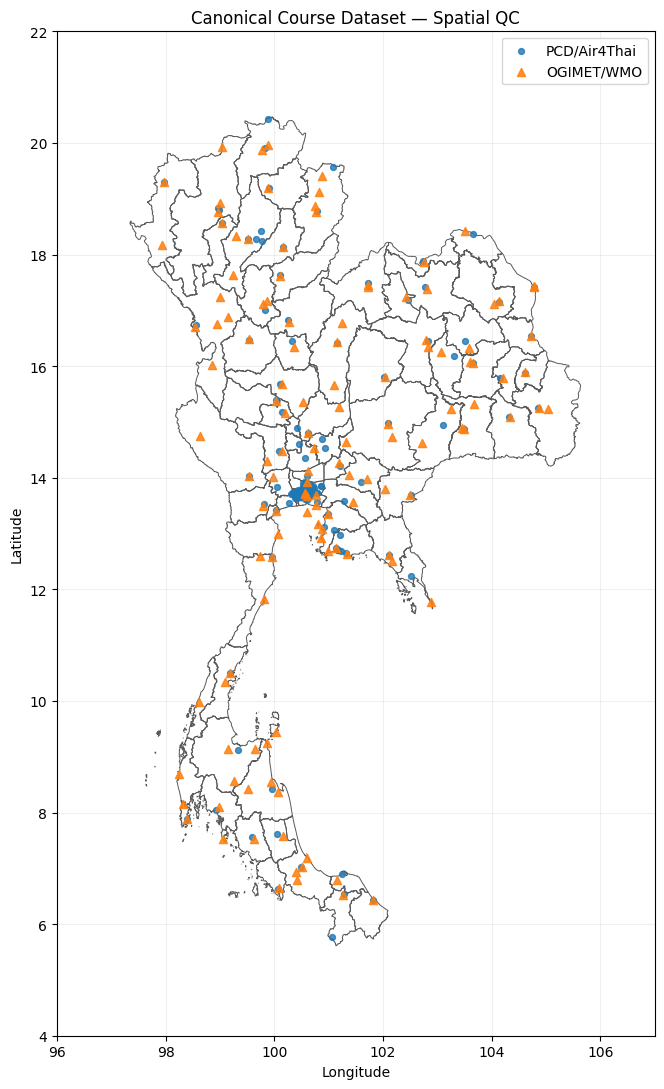

Saved: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/00_instructor_build/v1/Teaching_PCD_Environmental_GIS_Data_v1/metadata/00_spatial_QC_map.png


In [38]:
# CELL 37 — Quick QC map

fig, ax = plt.subplots(
    figsize=(9, 11)
)

province.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.35",
    linewidth=0.7,
)

pcd_station_enriched.plot(
    ax=ax,
    markersize=18,
    alpha=0.8,
    label="PCD/Air4Thai",
)

if len(ogimet_station_enriched) > 0:
    ogimet_station_enriched.plot(
        ax=ax,
        marker="^",
        markersize=34,
        alpha=0.85,
        label="OGIMET/WMO",
    )

ax.set_xlim(96, 107)
ax.set_ylim(4, 22)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    "Canonical Course Dataset — Spatial QC"
)
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()

QC_MAP_PATH = (
    METADATA_DIR
    / "00_spatial_QC_map.png"
)

fig.savefig(
    QC_MAP_PATH,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print("Saved:", QC_MAP_PATH)

# 0.12 Data dictionary and provenance

ไม่เดาความหมายของ raw PCD fields หาก source ไม่ได้อธิบายไว้

สำหรับ raw Excel จะบันทึก field name, dtype และปีที่พบ

In [39]:
# CELL 38 — Build course data dictionary

dictionary_rows = [
    {
        "dataset": "PCD station",
        "field": "station_id",
        "meaning":
            "PCD/Air4Thai station identifier",
        "unit": None,
        "role": "identifier",
    },
    {
        "dataset": "PCD station",
        "field": "latitude",
        "meaning": "Station latitude",
        "unit": "degree north",
        "role": "coordinate",
    },
    {
        "dataset": "PCD station",
        "field": "longitude",
        "meaning": "Station longitude",
        "unit": "degree east",
        "role": "coordinate",
    },
    {
        "dataset": "OGIMET/WMO station",
        "field": "wmo_id",
        "meaning":
            "WMO station identifier found in course sources",
        "unit": None,
        "role": "identifier",
    },
    {
        "dataset": "OGIMET/WMO station",
        "field": "elevation_m",
        "meaning":
            "Station elevation when available",
        "unit": "m",
        "role": "attribute",
    },
]

for field in [
    "province_code",
    "province_name_en",
    "province_name_th",
    "amphoe_code",
    "amphoe_name_en",
    "amphoe_name_th",
    "tambon_code",
    "tambon_name_en",
    "tambon_name_th",
]:
    dictionary_rows.append({
        "dataset":
            "Administrative GIS",
        "field":
            field,
        "meaning":
            (
                "Standardized administrative field "
                "derived from source attributes/spatial hierarchy"
            ),
        "unit":
            None,
        "role":
            "administrative attribute",
    })


if not pcd_excel_field_summary.empty:

    for _, row in pcd_excel_field_summary.iterrows():

        dictionary_rows.append({
            "dataset":
                "Raw PCD Excel",
            "field":
                row["field"],
            "meaning":
                (
                    "Raw field retained from source workbook; "
                    "interpret using source workbook/context."
                ),
            "unit":
                None,
            "role":
                (
                    "raw attribute; years present: "
                    + str(row["years_present"])
                ),
        })


course_data_dictionary = pd.DataFrame(
    dictionary_rows
)

display(
    course_data_dictionary.head(20)
)

,dataset,field,meaning,unit,role
0,PCD station,station_id,PCD/Air4Thai station identifier,NaN,identifier
1,PCD station,latitude,Station latitude,degree north,coordinate
2,PCD station,longitude,Station longitude,degree east,coordinate
3,OGIMET/WMO station,wmo_id,WMO station identifier found in course sources,NaN,identifier
4,OGIMET/WMO station,elevation_m,Station elevation when available,m,attribute
5,Administrative GIS,province_code,Standardized administrative field derived from...,NaN,administrative attribute
6,Administrative GIS,province_name_en,Standardized administrative field derived from...,NaN,administrative attribute
7,Administrative GIS,province_name_th,Standardized administrative field derived from...,NaN,administrative attribute
8,Administrative GIS,amphoe_code,Standardized administrative field derived from...,NaN,administrative attribute
9,Administrative GIS,amphoe_name_en,Standardized administrative field derived from...,NaN,administrative attribute


In [40]:
# CELL 39 — Data provenance

data_provenance = pd.DataFrame([
    {
        "dataset":
            "PCD Excel 2021–2025",
        "primary_source":
            "nattaponm/training_PCD_data_GIS",
        "source_location":
            "GitHub files 2021.xlsx–2025.xlsx",
        "processing":
            "Copied unchanged",
        "canonical_output":
            "raw_reference/PCD_Excel",
        "build_utc":
            RUN_UTC.isoformat(),
    },
    {
        "dataset":
            "PCD/Air4Thai station metadata",
        "primary_source":
            (
                "Existing course GitHub sources; "
                "Air4Thai public metadata fallback if required"
            ),
        "source_location":
            (
                air4thai_url_used
                if live_air4thai_used
                else "existing GitHub source data/code"
            ),
        "processing":
            (
                "coordinate QC; deduplication; "
                "spatial join to admin areas"
            ),
        "canonical_output":
            "processed/pcd_air4thai_stations.csv",
        "build_utc":
            RUN_UTC.isoformat(),
    },
    {
        "dataset":
            "OGIMET/WMO station metadata",
        "primary_source":
            (
                "nattaponm/"
                "training_PCD_Ogimet10yr_3provinces_pm25"
            ),
        "source_location":
            "station metadata discovered in course data/code",
        "processing":
            (
                "table/literal extraction; coordinate QC; "
                "deduplication; spatial join"
            ),
        "canonical_output":
            (
                "processed/"
                "ogimet_wmo_stations_from_course_sources.csv"
            ),
        "build_utc":
            RUN_UTC.isoformat(),
    },
])

for level in [
    "province",
    "amphoe",
    "tambon",
]:
    data_provenance.loc[
        len(data_provenance)
    ] = {
        "dataset":
            f"Thailand {level} boundaries",
        "primary_source":
            "prasertcbs/thailand_gis",
        "source_location":
            THAILAND_GIS_SOURCE[
                level
            ]["github_path"],
        "processing":
            (
                "extract simplified shapefile; "
                "geometry validation; EPSG:4326 normalization"
            ),
        "canonical_output":
            (
                "processed/"
                "environmental_gis_course.gpkg:"
                + level
            ),
        "build_utc":
            RUN_UTC.isoformat(),
    }


display(data_provenance)

,dataset,primary_source,source_location,processing,canonical_output,build_utc
0,PCD Excel 2021–2025,nattaponm/training_PCD_data_GIS,GitHub files 2021.xlsx–2025.xlsx,Copied unchanged,raw_reference/PCD_Excel,2026-08-22T11:31:27.298476+00:00
1,PCD/Air4Thai station metadata,Existing course GitHub sources; Air4Thai publi...,https://air4thai.pcd.go.th/services/getNewAQI_...,coordinate QC; deduplication; spatial join to ...,processed/pcd_air4thai_stations.csv,2026-08-22T11:31:27.298476+00:00
2,OGIMET/WMO station metadata,nattaponm/training_PCD_Ogimet10yr_3provinces_pm25,station metadata discovered in course data/code,table/literal extraction; coordinate QC; dedup...,processed/ogimet_wmo_stations_from_course_sour...,2026-08-22T11:31:27.298476+00:00
3,Thailand province boundaries,prasertcbs/thailand_gis,province/province_simplify.zip,extract simplified shapefile; geometry validat...,processed/environmental_gis_course.gpkg:province,2026-08-22T11:31:27.298476+00:00
4,Thailand amphoe boundaries,prasertcbs/thailand_gis,amphoe/thailand_province_amphoe_simplify.zip,extract simplified shapefile; geometry validat...,processed/environmental_gis_course.gpkg:amphoe,2026-08-22T11:31:27.298476+00:00
5,Thailand tambon boundaries,prasertcbs/thailand_gis,tambon_simplify/tha_admbnda_adm3_rtsd_20220121...,extract simplified shapefile; geometry validat...,processed/environmental_gis_course.gpkg:tambon,2026-08-22T11:31:27.298476+00:00


# 0.13 Save all metadata reports

In [41]:
# CELL 40 — Save metadata tables

metadata_tables = {
    "source_inventory.csv":
        source_inventory,
    "repository_download_summary.csv":
        repository_download_summary,
    "pcd_excel_file_status.csv":
        pcd_excel_file_status,
    "pcd_excel_schema.csv":
        pcd_excel_schema,
    "pcd_excel_field_inventory.csv":
        pcd_excel_field_inventory,
    "pcd_excel_completeness.csv":
        pcd_excel_field_summary,
    "pcd_station_qc.csv":
        pcd_station_qc,
    "ogimet_station_qc.csv":
        ogimet_station_qc,
    "gis_source_inventory.csv":
        gis_source_inventory,
    "gis_validation_report.csv":
        gis_validation_report,
    "admin_attribute_mapping.csv":
        admin_attribute_mapping,
    "admin_hierarchy_qc.csv":
        admin_hierarchy_qc,
    "data_provenance.csv":
        data_provenance,
    "course_data_dictionary.csv":
        course_data_dictionary,
    "gpkg_reopen_test.csv":
        gpkg_reopen_test,
}

for filename, table in metadata_tables.items():

    output = METADATA_DIR / filename

    table.to_csv(
        output,
        index=False,
        encoding="utf-8-sig",
    )

    print("Saved:", filename)

Saved: source_inventory.csv
Saved: repository_download_summary.csv
Saved: pcd_excel_file_status.csv
Saved: pcd_excel_schema.csv
Saved: pcd_excel_field_inventory.csv
Saved: pcd_excel_completeness.csv
Saved: pcd_station_qc.csv
Saved: ogimet_station_qc.csv
Saved: gis_source_inventory.csv
Saved: gis_validation_report.csv
Saved: admin_attribute_mapping.csv
Saved: admin_hierarchy_qc.csv
Saved: data_provenance.csv
Saved: course_data_dictionary.csv
Saved: gpkg_reopen_test.csv


In [42]:
# CELL 41 — Generate README_DATASET.md
import textwrap

dataset_readme = f"""
# Teaching PCD Environmental GIS — Dataset {DATASET_VERSION}

Canonical teaching dataset for Python, Pandas, GeoPandas,
air-quality GIS, meteorological station analysis,
spatiotemporal analysis, and spatial statistics.

## Build

- Dataset version: {DATASET_VERSION}
- Build UTC: {RUN_UTC.isoformat()}
- Course repository: {COURSE_REPOSITORY}

## PCD raw teaching workbooks

- 2021.xlsx
- 2022.xlsx
- 2023.xlsx
- 2024.xlsx
- 2025.xlsx

Source:
nattaponm/training_PCD_data_GIS

## PCD/Air4Thai station layer

- processed/pcd_air4thai_stations.csv
- processed/pcd_air4thai_stations.geojson
- GeoPackage layer: pcd_stations

Station count:
{pcd_station_enriched["station_id"].nunique()}

## Thailand meteorological-station network

- processed/thailand_meteorological_stations_from_course_sources.csv
- processed/thailand_meteorological_stations_from_course_sources.geojson
- GeoPackage layer: met_stations_thailand

Active station count found in the embedded course source:
{len(thailand_met_network_enriched)}

## OGIMET/WMO station layer

- processed/ogimet_wmo_stations_from_course_sources.csv
- processed/ogimet_wmo_stations_from_course_sources.geojson
- GeoPackage layer: ogimet_stations

Station count:
{ogimet_station_enriched["wmo_id"].nunique()}

Important:
This station list is collected from existing course sources.
Do not describe it as a complete national WMO network
unless separately verified.

## Thailand administrative GIS

Source:
https://github.com/prasertcbs/thailand_gis

Canonical file:
processed/environmental_gis_course.gpkg

Layers:
- province
- amphoe
- tambon
- pcd_stations
- ogimet_stations

Canonical CRS:
EPSG:4326

## Student-use principle

Student notebooks should use the canonical course packages
from Teaching_PCD_Environmental_GIS and should not
re-download external environmental datasets.

## QC and provenance

See files under metadata/.
"""

README_DATASET_PATH = (
    PACKAGE_ROOT / "README_DATASET.md"
)

README_DATASET_PATH.write_text(
    textwrap.dedent(
        dataset_readme
    ).strip()
    + "\n",
    encoding="utf-8",
)

print("Saved:", README_DATASET_PATH)


Saved: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/00_instructor_build/v1/Teaching_PCD_Environmental_GIS_Data_v1/README_DATASET.md


In [43]:
# CELL 42 — Dataset manifest

manifest_rows = []

for path in PACKAGE_ROOT.rglob("*"):

    if not path.is_file():
        continue

    if path.name == "dataset_manifest.csv":
        continue

    manifest_rows.append({
        "relative_path":
            str(
                path.relative_to(
                    PACKAGE_ROOT
                )
            ),
        "size_MB":
            file_size_mb(path),
        "sha256":
            sha256_file(path),
    })


dataset_manifest = (
    pd.DataFrame(manifest_rows)
    .sort_values("relative_path")
    .reset_index(drop=True)
)

DATASET_MANIFEST_PATH = (
    METADATA_DIR
    / "dataset_manifest.csv"
)

dataset_manifest.to_csv(
    DATASET_MANIFEST_PATH,
    index=False,
)

display(dataset_manifest)

,relative_path,size_MB,sha256
0,README_DATASET.md,0.001700,ed32487a7e84ce02de3c602eae21f04a928047601d4384...
1,metadata/00_spatial_QC_map.png,0.440454,71aa0ffeb514e0ee57b7220297430cf7ef7c1ced8867d3...
2,metadata/admin_attribute_mapping.csv,0.000669,7bd1a616b9a07afaad58365ec35db9820d38a926db97aa...
3,metadata/admin_hierarchy_qc.csv,0.000236,447da32b6e87c4edc0798d408e04bf59288ea61771fc11...
4,metadata/course_data_dictionary.csv,0.019364,2137a54eb4d0df79b7921d850dbee0e82b23805a9c3ad0...
5,metadata/data_provenance.csv,0.001492,6997afb271185015544df4f87b6d342cd61cb06f8c026d...
6,metadata/gis_source_inventory.csv,0.001349,dc204a50ca8444ee31e4abb7175872da9c58b3983c02f0...
7,metadata/gis_validation_report.csv,0.000970,1b710e6bd71d776ef648a4df32dbfa765f46613d83185a...
8,metadata/gpkg_reopen_test.csv,0.000237,c0c233f08785cca2baca3e16805c893248db22ae83ee31...
9,metadata/ogimet_station_qc.csv,0.000199,393010b903315a62cd970e46c0762a230f8f074a19d98c...


# 0.14 Final acceptance test

Canonical data จะยังไม่ถือว่า GitHub-ready หากมี `FAIL`

`CHECK` หมายถึงต้องตรวจด้วยตา/ทบทวนก่อนอัปโหลด

In [44]:
# CELL 43 — Acceptance test

pcd_excel_pass = (
    (
        pcd_excel_file_status[
            "status"
        ]
        == "COPIED"
    ).sum()
    == 5
)

pcd_unique_pass = (
    pcd_station_enriched[
        "station_id"
    ].nunique()
    == len(pcd_station_enriched)
)

pcd_province_match_pct = (
    pcd_station_enriched[
        "province_name_en"
    ]
    .notna()
    .mean()
    * 100
)

ogimet_unique_pass = (
    "wmo_id" in ogimet_station_enriched.columns
    and len(ogimet_station_enriched) > 0
    and ogimet_station_enriched[
        "wmo_id"
    ].nunique()
    == len(ogimet_station_enriched)
)

gis_invalid_after = int(
    gis_validation_report[
        "invalid_after_n"
    ].sum()
)

gpkg_layers_pass = (
    gpkg_reopen_test[
        "status"
    ]
    .eq("PASS")
    .all()
)

gpkg_crs_pass = (
    gpkg_reopen_test[
        "crs"
    ]
    .astype(str)
    .str.contains(
        "4326",
        regex=False,
    )
    .all()
)


acceptance_test = pd.DataFrame([
    {
        "test":
            "PCD Excel 2021–2025",
        "status":
            (
                "PASS"
                if pcd_excel_pass
                else "FAIL"
            ),
        "detail":
            (
                f"{(
                    pcd_excel_file_status['status']
                    == 'COPIED'
                ).sum()}/5 files"
            ),
    },
    {
        "test":
            "PCD station IDs unique",
        "status":
            (
                "PASS"
                if pcd_unique_pass
                else "FAIL"
            ),
        "detail":
            (
                f"{len(pcd_station_enriched)} rows"
            ),
    },
    {
        "test":
            "PCD stations matched to province",
        "status":
            (
                "PASS"
                if pcd_province_match_pct >= 95
                else "CHECK"
            ),
        "detail":
            f"{pcd_province_match_pct:.1f}%",
    },
    {
        "test":
            "OGIMET station metadata available",
        "status":
            (
                "PASS"
                if len(ogimet_station_enriched) > 0
                else "FAIL"
            ),
        "detail":
            f"{len(ogimet_station_enriched)} station(s)",
    },
    {
        "test":
            "OGIMET WMO IDs unique",
        "status":
            (
                "PASS"
                if ogimet_unique_pass
                else "CHECK"
            ),
        "detail":
            (
                f"{ogimet_station_enriched['wmo_id'].nunique()} "
                "unique IDs"
            ),
    },
    {
        "test":
            "Province feature count",
        "status":
            (
                "PASS"
                if len(province) == 77
                else "FAIL"
            ),
        "detail":
            str(len(province)),
    },
    {
        "test":
            "GIS invalid geometries after repair",
        "status":
            (
                "PASS"
                if gis_invalid_after == 0
                else "FAIL"
            ),
        "detail":
            str(gis_invalid_after),
    },
    {
        "test":
            "GeoPackage layers re-open",
        "status":
            (
                "PASS"
                if gpkg_layers_pass
                else "FAIL"
            ),
        "detail":
            (
                f"{gpkg_reopen_test['status'].eq('PASS').sum()}"
                f"/{len(gpkg_reopen_test)}"
            ),
    },
    {
        "test":
            "Canonical CRS = EPSG:4326",
        "status":
            (
                "PASS"
                if gpkg_crs_pass
                else "FAIL"
            ),
        "detail":
            "EPSG:4326",
    },
])


ACCEPTANCE_PATH = (
    METADATA_DIR
    / "acceptance_test.csv"
)

acceptance_test.to_csv(
    ACCEPTANCE_PATH,
    index=False,
)

display(acceptance_test)

,test,status,detail
0,PCD Excel 2021–2025,PASS,5/5 files
1,PCD station IDs unique,PASS,173 rows
2,PCD stations matched to province,PASS,100.0%
3,OGIMET station metadata available,PASS,130 station(s)
4,OGIMET WMO IDs unique,PASS,130 unique IDs
5,Province feature count,PASS,77
6,GIS invalid geometries after repair,PASS,0
7,GeoPackage layers re-open,PASS,6/6
8,Canonical CRS = EPSG:4326,PASS,EPSG:4326


# 0.15 Create GitHub-ready ZIP packages

สร้าง 3 ไฟล์ที่ Notebook 01 จะดาวน์โหลด:

```text
Teaching_PCD_Environmental_GIS_Core_v1.zip
Teaching_PCD_Environmental_GIS_PCD_Excel_v1.zip
Teaching_PCD_Environmental_GIS_GIS_Source_v1.zip
```

แยกเป็น 3 packages เพื่อควบคุมขนาดไฟล์ GitHub และให้ provenance ชัดเจน

In [45]:
# CELL 44 — ZIP helper

def zip_paths(
    source_paths,
    output_zip,
    root_for_arcname,
):
    output_zip = Path(output_zip)

    if output_zip.exists():
        output_zip.unlink()

    with zipfile.ZipFile(
        output_zip,
        "w",
        compression=zipfile.ZIP_DEFLATED,
        compresslevel=6,
    ) as zf:

        for source in source_paths:

            source = Path(source)

            if source.is_file():
                zf.write(
                    source,
                    arcname=str(
                        source.relative_to(
                            root_for_arcname
                        )
                    ),
                )

            elif source.is_dir():
                for path in source.rglob("*"):

                    if not path.is_file():
                        continue

                    zf.write(
                        path,
                        arcname=str(
                            path.relative_to(
                                root_for_arcname
                            )
                        ),
                    )

    return output_zip

In [46]:
# CELL 45 — Create ZIP packages

CORE_ZIP = (
    GITHUB_READY_DIR
    / (
        "Teaching_PCD_Environmental_GIS_"
        f"Core_{DATASET_VERSION}.zip"
    )
)

PCD_EXCEL_ZIP = (
    GITHUB_READY_DIR
    / (
        "Teaching_PCD_Environmental_GIS_"
        f"PCD_Excel_{DATASET_VERSION}.zip"
    )
)

GIS_SOURCE_ZIP = (
    GITHUB_READY_DIR
    / (
        "Teaching_PCD_Environmental_GIS_"
        f"GIS_Source_{DATASET_VERSION}.zip"
    )
)


zip_paths(
    [
        PROCESSED_DIR,
        METADATA_DIR,
        README_DATASET_PATH,
    ],
    CORE_ZIP,
    PACKAGE_ROOT,
)

zip_paths(
    [RAW_PCD_DIR],
    PCD_EXCEL_ZIP,
    RAW_REFERENCE_DIR,
)

zip_paths(
    [RAW_GIS_DIR],
    GIS_SOURCE_ZIP,
    RAW_REFERENCE_DIR,
)


package_rows = []

for package_type, path in [
    ("core", CORE_ZIP),
    ("pcd_excel", PCD_EXCEL_ZIP),
    ("gis_source", GIS_SOURCE_ZIP),
]:

    package_rows.append({
        "package_type":
            package_type,
        "filename":
            path.name,
        "size_MB":
            file_size_mb(path),
        "sha256":
            sha256_file(path),
        "github_file_size_ok":
            (
                file_size_mb(path)
                < 95
            ),
    })


package_inventory = pd.DataFrame(
    package_rows
)

package_inventory[
    "required_for_students"
] = True

display(package_inventory)

,package_type,filename,size_MB,sha256,github_file_size_ok,required_for_students
0,core,Teaching_PCD_Environmental_GIS_Core_v1.zip,6.841057,c9e335506b7c1a30335ead5e04a04d6c1ed871251ccb3f...,True,True
1,pcd_excel,Teaching_PCD_Environmental_GIS_PCD_Excel_v1.zip,0.999607,1639949d55c2f35e0bf8cd0666bad4e44c65144d03d769...,True,True
2,gis_source,Teaching_PCD_Environmental_GIS_GIS_Source_v1.zip,5.560163,41c23cff60de3d448085cfb71b28876b1ff43c86743840...,True,True


In [47]:
# CELL 46 — GitHub upload manifest and SHA256

PACKAGE_MANIFEST_CSV = (
    GITHUB_READY_DIR
    / "dataset_packages.csv"
)

package_inventory.to_csv(
    PACKAGE_MANIFEST_CSV,
    index=False,
)


SHA256_FILE = (
    GITHUB_READY_DIR
    / "dataset_packages.sha256"
)

SHA256_FILE.write_text(
    "\n".join(
        (
            row["sha256"]
            + "  "
            + row["filename"]
        )
        for _, row
        in package_inventory.iterrows()
    )
    + "\n",
    encoding="utf-8",
)


shutil.copy2(
    README_DATASET_PATH,
    GITHUB_READY_DIR
    / "README_DATASET.md",
)

print("GitHub-ready files:")

for path in sorted(
    GITHUB_READY_DIR.iterdir()
):
    if path.is_file():
        print(
            f"{path.name:70s} "
            f"{file_size_mb(path):8.2f} MB"
        )

GitHub-ready files:
README_DATASET.md                                                          0.00 MB
Teaching_PCD_Environmental_GIS_Core_v1.zip                                 6.84 MB
Teaching_PCD_Environmental_GIS_GIS_Source_v1.zip                           5.56 MB
Teaching_PCD_Environmental_GIS_PCD_Excel_v1.zip                            1.00 MB
dataset_packages.csv                                                       0.00 MB
dataset_packages.sha256                                                    0.00 MB


In [48]:
# CELL 47 — Final GitHub-readiness decision

fail_count = int(
    acceptance_test[
        "status"
    ]
    .eq("FAIL")
    .sum()
)

check_count = int(
    acceptance_test[
        "status"
    ]
    .eq("CHECK")
    .sum()
)

oversize_n = int(
    (
        ~package_inventory[
            "github_file_size_ok"
        ]
    ).sum()
)

github_ready_status = (
    "GITHUB_READY"
    if (
        fail_count == 0
        and oversize_n == 0
    )
    else "NOT_READY"
)


final_build_summary = pd.DataFrame([
    {
        "dataset_version":
            DATASET_VERSION,
        "build_utc":
            RUN_UTC.isoformat(),
        "acceptance_fail_n":
            fail_count,
        "acceptance_check_n":
            check_count,
        "oversize_package_n":
            oversize_n,
        "status":
            github_ready_status,
        "github_ready_directory":
            str(GITHUB_READY_DIR),
    }
])


FINAL_BUILD_SUMMARY = (
    GITHUB_READY_DIR
    / "final_build_summary.csv"
)

final_build_summary.to_csv(
    FINAL_BUILD_SUMMARY,
    index=False,
)


display(final_build_summary)

print("\n==============================")
print("COURSE DATA BUILD STATUS")
print("==============================")
print(github_ready_status)

if github_ready_status == "GITHUB_READY":
    print(
        "\nUpload files from:"
    )
    print(GITHUB_READY_DIR)
    print(
        "\nto repository:"
    )
    print(COURSE_REPOSITORY)
else:
    print(
        "\nInspect acceptance_test.csv "
        "and dataset_packages.csv before upload."
    )

,dataset_version,build_utc,acceptance_fail_n,acceptance_check_n,oversize_package_n,status,github_ready_directory
0,v1,2026-08-22T11:31:27.298476+00:00,0,0,0,GITHUB_READY,/content/drive/MyDrive/Teaching_PCD_Environmen...



COURSE DATA BUILD STATUS
GITHUB_READY

Upload files from:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/01_GitHub_ready/v1

to repository:
https://github.com/nattaponm/Teaching_PCD_Environmental_GIS


# ตรวจด้วยตาก่อนอัปโหลด

แม้ automated test ผ่าน ควรตรวจ:

1. QC map — PCD/OGIMET points อยู่ในตำแหน่งสมเหตุสมผล
2. PCD station table — station ID/name/lat/lon/admin areas
3. OGIMET table — WMO/name/lat/lon/elevation/source file
4. Province = 77
5. Amphoe/Tambon geometry ดูสมเหตุสมผล
6. CRS = EPSG:4326
7. `CHECK` ทุกข้อมีคำอธิบายก่อนประกาศ canonical dataset

---

# ไฟล์ที่ควรอัปโหลดเข้า `Teaching_PCD_Environmental_GIS`

จาก `01_GitHub_ready/v1/`

```text
Teaching_PCD_Environmental_GIS_Core_v1.zip
Teaching_PCD_Environmental_GIS_PCD_Excel_v1.zip
Teaching_PCD_Environmental_GIS_GIS_Source_v1.zip
README_DATASET.md
dataset_packages.csv
dataset_packages.sha256
final_build_summary.csv
```

Notebook 01 จะดาวน์โหลดข้อมูลจาก repository ใหม่นี้เพียงแหล่งเดียว

# Notebook ต่อไป

## `01_get_course_dataset_from_GitHub.ipynb`

สำหรับนักศึกษา:

```text
mount Google Drive
        ↓
read dataset_packages.csv
        ↓
download canonical ZIPs
        ↓
verify SHA256
        ↓
unzip
        ↓
validate required files/layers
        ↓
TEACHING DATASET READY
```

จาก Notebook 01 เป็นต้นไป **ไม่ดึง PCD/Air4Thai, OGIMET หรือ thailand_gis จาก external source อีก**